### Musical Instruments Recommendation Benchmark


Amazon Reviews Dataset


<a id='table-of-contents'></a>
#### Contents
- [1. Environment Setup](#section-1-environment-setup)
- [2. Unified Experimental Protocol](#section-2-unified-experimental-protocol)
- [3. Data Pipeline](#section-3-data-pipeline)
- [4. Baseline Rating Models](#section-4-baseline-rating-models)
- [5. Baseline Ranking Models](#section-5-baseline-ranking-models)
- [6. Ranking Extensions](#section-6-ranking-extensions)
  - [6.1 Residual Linear Reranking](#section-61-residual-linear-reranking)
  - [6.2 Residual MLP Reranking](#section-62-residual-mlp-reranking)
  - [6.3 SimGCL Ranking](#section-63-simgcl-ranking)
  - [6.4 SVD Graph Fusion](#section-64-svd-graph-fusion)
  - [6.5 GATv2-BPR](#section-65-gatv2-bpr)
  - [6.6 LightGCL-BPR](#section-66-lightgcl-bpr)
- [7. Final Comparison](#section-7-final-comparison)

<a id='section-1-environment-setup'></a>
#### 1. Environment Setup


In [43]:
import os
import random
import time
import warnings
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse.linalg import svds
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from IPython.display import display

from models.lightgcn import LightGCN
from models.two_tower import TwoTowerMLP
from training.datasets import BPRDataset, RatingDataset, build_user_positive_items
from training.lightgcn_bpr import train_lightgcn_bpr_epoch
from training.lightgcn_mse import evaluate_lightgcn_mse, train_lightgcn_mse_epoch
from training.two_tower_bpr import train_two_tower_bpr_epoch
from training.two_tower_mse import evaluate_mse_model, train_two_tower_mse_epoch

warnings.filterwarnings('ignore')


try:
    from torch_geometric.nn import GATv2Conv
    HAS_TORCH_GEOMETRIC = True
    GATV2_IMPORT_ERROR = None
except Exception as exc:
    HAS_TORCH_GEOMETRIC = False
    GATV2_IMPORT_ERROR = repr(exc)

SEED = 42

def set_global_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_global_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
project_root = Path.cwd()
data_dir = project_root / 'data'
model_dir = project_root / 'model_pth'
results_dir = project_root / 'results'
model_dir.mkdir(exist_ok=True)
results_dir.mkdir(exist_ok=True)

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'Using device: {device}')
print(f'Project root: {project_root}')
print(f'Global seed fixed at: {SEED}')


PyTorch version: 2.9.1+cu130
CUDA available: True
Using device: cuda
Project root: c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep Learning\Final Project\Project
Global seed fixed at: 42


<a id='section-2-unified-experimental-protocol'></a>
#### 2. Unified Experimental Protocol


In [44]:
EXPERIMENT_CONFIG = {
    'dataset_name': 'Amazon Musical Instruments',
    'ratings_path': data_dir / 'ratings_Musical_Instruments.csv',
    'k_core': 3,
    'ranking_top_k': 10,
    'relevance_threshold': 4.0,
    'embedding_dim': 64,
    'lightgcn_layers': 3,
    'two_tower_hidden_dims': [128, 64],
    'batch_size': 1024,
    'mse_epochs': 20,
    'mse_patience': 5,
    'bpr_epochs': 50,
    'bpr_patience': 5,
    'lr': 1e-3,
    'reg_weight': 1e-4,
    'force_retrain': False,
}

MODEL_PATHS = {
    'two_tower_mse': model_dir / 'recon_combined_two_tower_mse.pth',
    'lightgcn_mse': model_dir / 'recon_combined_lightgcn_mse.pth',
    'two_tower_bpr': model_dir / 'recon_combined_two_tower_bpr.pth',
    'lightgcn_bpr': model_dir / 'recon_combined_lightgcn_bpr.pth',
    'residual_linear': model_dir / 'recon_combined_residual_linear.pth',
    'residual_mlp': model_dir / 'recon_combined_residual_mlp.pth',
    'gat_bpr': model_dir / 'recon_combined_gat_bpr.pth',
    'lightgcl_bpr': model_dir / 'recon_combined_lightgcl_bpr.pth',
}

print(pd.Series({k: str(v) if isinstance(v, Path) else v for k, v in EXPERIMENT_CONFIG.items()}))
print('\nModel checkpoints:')
for name, path in MODEL_PATHS.items():
    print(f'- {name}: {path.name}')

dataset_name                                    Amazon Musical Instruments
ratings_path             c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
k_core                                                                   3
ranking_top_k                                                           10
relevance_threshold                                                    4.0
embedding_dim                                                           64
lightgcn_layers                                                          3
two_tower_hidden_dims                                            [128, 64]
batch_size                                                            1024
mse_epochs                                                              20
mse_patience                                                             5
bpr_epochs                                                              50
bpr_patience                                                             5
lr                       

<a id='section-3-data-pipeline'></a>
#### 3. Data Pipeline


In [45]:
def load_ratings_data(csv_path: Path) -> pd.DataFrame:
    column_names = ['user_id', 'item_id', 'rating', 'timestamp']
    preview = pd.read_csv(csv_path, nrows=5, header=None)

    if preview.shape[1] < 4:
        raise ValueError(f'Expected at least 4 columns in {csv_path}, got {preview.shape[1]}.')

    first_value = str(preview.iloc[0, 0]).strip().lower()
    has_header = first_value in {'user_id', 'reviewerid'}

    if has_header:
        ratings_frame = pd.read_csv(csv_path)
        rename_map = {
            'reviewerID': 'user_id',
            'asin': 'item_id',
            'overall': 'rating',
            'unixReviewTime': 'timestamp',
        }
        ratings_frame = ratings_frame.rename(columns=rename_map)
        missing = [col for col in column_names if col not in ratings_frame.columns]
        if missing:
            raise ValueError(f'Missing expected columns after header-based load: {missing}')
        ratings_frame = ratings_frame[column_names].copy()
    else:
        ratings_frame = pd.read_csv(csv_path, header=None, names=column_names, usecols=[0, 1, 2, 3])

    ratings_frame['rating'] = ratings_frame['rating'].astype(float)
    ratings_frame['timestamp'] = ratings_frame['timestamp'].astype(int)
    return ratings_frame


def filter_kcore(ratings_frame: pd.DataFrame, k: int = 3) -> pd.DataFrame:
    filtered_frame = ratings_frame.copy()
    while True:
        user_counts = filtered_frame['user_id'].value_counts()
        item_counts = filtered_frame['item_id'].value_counts()
        valid_users = user_counts[user_counts >= k].index
        valid_items = item_counts[item_counts >= k].index
        next_frame = filtered_frame[
            filtered_frame['user_id'].isin(valid_users)
            & filtered_frame['item_id'].isin(valid_items)
        ]
        if len(next_frame) == len(filtered_frame):
            return next_frame
        filtered_frame = next_frame

def temporal_split(ratings_frame: pd.DataFrame):
    sorted_ratings = ratings_frame.sort_values('timestamp')
    test_frame = sorted_ratings.groupby('user_idx').tail(1)
    train_val_frame = sorted_ratings[~sorted_ratings.index.isin(test_frame.index)]
    val_frame = train_val_frame.groupby('user_idx').tail(1)
    train_frame = train_val_frame[~train_val_frame.index.isin(val_frame.index)]
    return train_frame, val_frame, test_frame

def build_normalized_adj_matrix(train_df: pd.DataFrame, n_users: int, n_items: int) -> torch.Tensor:
    user_indices = train_df['user_idx'].to_numpy(dtype=np.int64)
    item_indices = train_df['item_idx'].to_numpy(dtype=np.int64)
    row = np.concatenate([user_indices, item_indices + n_users])
    col = np.concatenate([item_indices + n_users, user_indices])
    data = np.ones(len(row), dtype=np.float32)
    adj_mat = sp.coo_matrix((data, (row, col)), shape=(n_users + n_items, n_users + n_items))
    rowsum = np.array(adj_mat.sum(1)).flatten()
    d_inv = np.zeros_like(rowsum, dtype=np.float32)
    np.power(rowsum, -0.5, out=d_inv, where=rowsum > 0)
    d_mat_inv = sp.diags(d_inv)
    norm_adj = d_mat_inv.dot(adj_mat).dot(d_mat_inv).tocoo()
    indices = torch.LongTensor(np.vstack((norm_adj.row, norm_adj.col)))
    values = torch.FloatTensor(norm_adj.data)
    shape = torch.Size(norm_adj.shape)
    return torch.sparse.FloatTensor(indices, values, shape).coalesce().to(device)

ratings_df = load_ratings_data(EXPERIMENT_CONFIG['ratings_path'])
ratings_filtered = filter_kcore(ratings_df, k=EXPERIMENT_CONFIG['k_core']).copy()

unique_users = ratings_filtered['user_id'].unique()
unique_items = ratings_filtered['item_id'].unique()
user_to_idx = {user_id: idx for idx, user_id in enumerate(unique_users)}
item_to_idx = {item_id: idx for idx, item_id in enumerate(unique_items)}
ratings_filtered['user_idx'] = ratings_filtered['user_id'].map(user_to_idx)
ratings_filtered['item_idx'] = ratings_filtered['item_id'].map(item_to_idx)

n_users = len(user_to_idx)
n_items = len(item_to_idx)
train_data, val_data, test_data = temporal_split(ratings_filtered)

train_dataset_mse = RatingDataset(train_data)
val_dataset_mse = RatingDataset(val_data)
test_dataset_mse = RatingDataset(test_data)

train_loader_mse = DataLoader(train_dataset_mse, batch_size=EXPERIMENT_CONFIG['batch_size'], shuffle=True)
val_loader_mse = DataLoader(val_dataset_mse, batch_size=EXPERIMENT_CONFIG['batch_size'], shuffle=False)
test_loader_mse = DataLoader(test_dataset_mse, batch_size=EXPERIMENT_CONFIG['batch_size'], shuffle=False)

user_positive_items = build_user_positive_items(train_data)
norm_adj_tensor = build_normalized_adj_matrix(train_data, n_users, n_items)

print(f'Ratings shape: {ratings_df.shape}')
print(f'Filtered interactions: {len(ratings_filtered):,}')
print(f'Users: {n_users:,}')
print(f'Items: {n_items:,}')
print(f'Train: {len(train_data):,} | Val: {len(val_data):,} | Test: {len(test_data):,}')
print(f'Adjacency nnz: {norm_adj_tensor._nnz():,}')


Ratings shape: (500176, 4)
Filtered interactions: 82,855
Users: 17,500
Items: 9,237
Train: 47,855 | Val: 17,500 | Test: 17,500
Adjacency nnz: 95,710


<a id='section-4-baseline-rating-models'></a>
#### 4. Baseline Rating Models


<a id='section-41-two-tower-with-mse'></a>
##### 4.1 Two Tower with MSE


- Path: user embedding + item embedding + two MLP towers + MSE loss
- Strengths: simple, scalable, strong explicit-rating baseline
- Weaknesses: weaker inductive bias for graph-based ranking

[[Back to Contents]](#table-of-contents)


In [46]:
set_global_seed(SEED)
print('Reseeded global RNG state for this section.')

def train_two_tower_mse_with_val(model, train_loader, val_loader, device, save_path):
    optimizer = torch.optim.Adam(model.parameters(), lr=EXPERIMENT_CONFIG['lr'])
    best_val_rmse = float('inf')
    patience_counter = 0
    history = {'train_losses': [], 'val_rmses': [], 'val_maes': []}
    for epoch in range(EXPERIMENT_CONFIG['mse_epochs']):
        train_loss = train_two_tower_mse_epoch(model, train_loader, optimizer, device)
        val_rmse, val_mae = evaluate_mse_model(model, val_loader, device)
        history['train_losses'].append(train_loss)
        history['val_rmses'].append(val_rmse)
        history['val_maes'].append(val_mae)
        print(f"Epoch {epoch + 1:02d} | Train Loss: {train_loss:.4f} | Val RMSE: {val_rmse:.4f} | Val MAE: {val_mae:.4f}")
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= EXPERIMENT_CONFIG['mse_patience']:
                print('Early stopping triggered.')
                break
    return history

two_tower_mse_model = TwoTowerMLP(
    n_users,
    n_items,
    embedding_dim=EXPERIMENT_CONFIG['embedding_dim'],
    hidden_dims=EXPERIMENT_CONFIG['two_tower_hidden_dims'],
).to(device)

if MODEL_PATHS['two_tower_mse'].exists() and not EXPERIMENT_CONFIG['force_retrain']:
    two_tower_mse_model.load_state_dict(torch.load(MODEL_PATHS['two_tower_mse'], map_location=device))
    two_tower_mse_history = None
    print('Loaded existing Two Tower MSE checkpoint.')
else:
    two_tower_mse_history = train_two_tower_mse_with_val(
        two_tower_mse_model,
        train_loader_mse,
        val_loader_mse,
        device,
        MODEL_PATHS['two_tower_mse'],
    )
    two_tower_mse_model.load_state_dict(torch.load(MODEL_PATHS['two_tower_mse'], map_location=device))

two_tower_mse_rmse, two_tower_mse_mae = evaluate_mse_model(two_tower_mse_model, test_loader_mse, device)
print(f'Two Tower MSE | Test RMSE: {two_tower_mse_rmse:.4f} | Test MAE: {two_tower_mse_mae:.4f}')


Reseeded global RNG state for this section.
Epoch 01 | Train Loss: 11.5942 | Val RMSE: 1.2855 | Val MAE: 0.9637
Epoch 02 | Train Loss: 1.2518 | Val RMSE: 1.0225 | Val MAE: 0.7768
Epoch 03 | Train Loss: 0.7423 | Val RMSE: 1.0465 | Val MAE: 0.7738
Epoch 04 | Train Loss: 0.6481 | Val RMSE: 1.0748 | Val MAE: 0.7841
Epoch 05 | Train Loss: 0.6143 | Val RMSE: 1.0937 | Val MAE: 0.7991
Epoch 06 | Train Loss: 0.5879 | Val RMSE: 1.1152 | Val MAE: 0.8150
Epoch 07 | Train Loss: 0.5723 | Val RMSE: 1.1273 | Val MAE: 0.8200
Early stopping triggered.
Two Tower MSE | Test RMSE: 1.0627 | Test MAE: 0.8033


<a id='section-42-lightgcn-with-mse'></a>
##### 4.2 LightGCN with MSE


- Path: LightGCN propagation + explicit-rating head + MSE loss
- Strengths: graph-aware collaborative signal for rating prediction
- Weaknesses: graph propagation is heavier than Two Tower

[[Back to Contents]](#table-of-contents)


In [47]:
set_global_seed(SEED)
print('Reseeded global RNG state for this section.')

def train_lightgcn_mse_with_val(model, adj_mat, train_loader, val_loader, device, save_path):
    optimizer = torch.optim.Adam(model.parameters(), lr=EXPERIMENT_CONFIG['lr'])
    best_val_rmse = float('inf')
    patience_counter = 0
    history = {'train_losses': [], 'val_rmses': [], 'val_maes': []}
    for epoch in range(EXPERIMENT_CONFIG['mse_epochs']):
        train_loss = train_lightgcn_mse_epoch(
            model,
            adj_mat,
            train_loader,
            optimizer,
            device,
            reg_weight=EXPERIMENT_CONFIG['reg_weight'],
        )
        val_rmse, val_mae = evaluate_lightgcn_mse(model, adj_mat, val_loader, device)
        history['train_losses'].append(train_loss)
        history['val_rmses'].append(val_rmse)
        history['val_maes'].append(val_mae)
        print(f"Epoch {epoch + 1:02d} | Train Loss: {train_loss:.4f} | Val RMSE: {val_rmse:.4f} | Val MAE: {val_mae:.4f}")
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= EXPERIMENT_CONFIG['mse_patience']:
                print('Early stopping triggered.')
                break
    return history

lightgcn_mse_model = LightGCN(
    n_users,
    n_items,
    embedding_dim=EXPERIMENT_CONFIG['embedding_dim'],
    n_layers=EXPERIMENT_CONFIG['lightgcn_layers'],
).to(device)

if MODEL_PATHS['lightgcn_mse'].exists() and not EXPERIMENT_CONFIG['force_retrain']:
    lightgcn_mse_model.load_state_dict(torch.load(MODEL_PATHS['lightgcn_mse'], map_location=device))
    lightgcn_mse_history = None
    print('Loaded existing LightGCN MSE checkpoint.')
else:
    lightgcn_mse_history = train_lightgcn_mse_with_val(
        lightgcn_mse_model,
        norm_adj_tensor,
        train_loader_mse,
        val_loader_mse,
        device,
        MODEL_PATHS['lightgcn_mse'],
    )
    lightgcn_mse_model.load_state_dict(torch.load(MODEL_PATHS['lightgcn_mse'], map_location=device))

lightgcn_mse_rmse, lightgcn_mse_mae = evaluate_lightgcn_mse(lightgcn_mse_model, norm_adj_tensor, test_loader_mse, device)
print(f'LightGCN MSE | Test RMSE: {lightgcn_mse_rmse:.4f} | Test MAE: {lightgcn_mse_mae:.4f}')


Reseeded global RNG state for this section.
Epoch 01 | Train Loss: 2.7456 | Val RMSE: 1.6656 | Val MAE: 1.5511
Epoch 02 | Train Loss: 2.4618 | Val RMSE: 1.6035 | Val MAE: 1.4954
Epoch 03 | Train Loss: 2.1234 | Val RMSE: 1.5253 | Val MAE: 1.4213
Epoch 04 | Train Loss: 1.7284 | Val RMSE: 1.4319 | Val MAE: 1.3247
Epoch 05 | Train Loss: 1.3882 | Val RMSE: 1.3494 | Val MAE: 1.2328
Epoch 06 | Train Loss: 1.1629 | Val RMSE: 1.2900 | Val MAE: 1.1629
Epoch 07 | Train Loss: 1.0248 | Val RMSE: 1.2489 | Val MAE: 1.1132
Epoch 08 | Train Loss: 0.9359 | Val RMSE: 1.2211 | Val MAE: 1.0787
Epoch 09 | Train Loss: 0.8743 | Val RMSE: 1.2017 | Val MAE: 1.0542
Epoch 10 | Train Loss: 0.8283 | Val RMSE: 1.1883 | Val MAE: 1.0370
Epoch 11 | Train Loss: 0.7915 | Val RMSE: 1.1787 | Val MAE: 1.0248
Epoch 12 | Train Loss: 0.7607 | Val RMSE: 1.1722 | Val MAE: 1.0163
Epoch 13 | Train Loss: 0.7336 | Val RMSE: 1.1682 | Val MAE: 1.0110
Epoch 14 | Train Loss: 0.7091 | Val RMSE: 1.1654 | Val MAE: 1.0071
Epoch 15 | Train L

<a id='section-43-rating-prediction-summary'></a>
##### 4.3 Rating Prediction Summary


In [48]:
rating_summary_df = pd.DataFrame([
    {'Model': 'Two Tower-MSE', 'Test RMSE': two_tower_mse_rmse, 'Test MAE': two_tower_mse_mae},
    {'Model': 'LightGCN-MSE', 'Test RMSE': lightgcn_mse_rmse, 'Test MAE': lightgcn_mse_mae},
])
rating_summary_df


,Model,Test RMSE,Test MAE
0,Two Tower-MSE,1.062712,0.803322
1,LightGCN-MSE,1.192730,1.030090


##### 4.4 Rating Model Curves


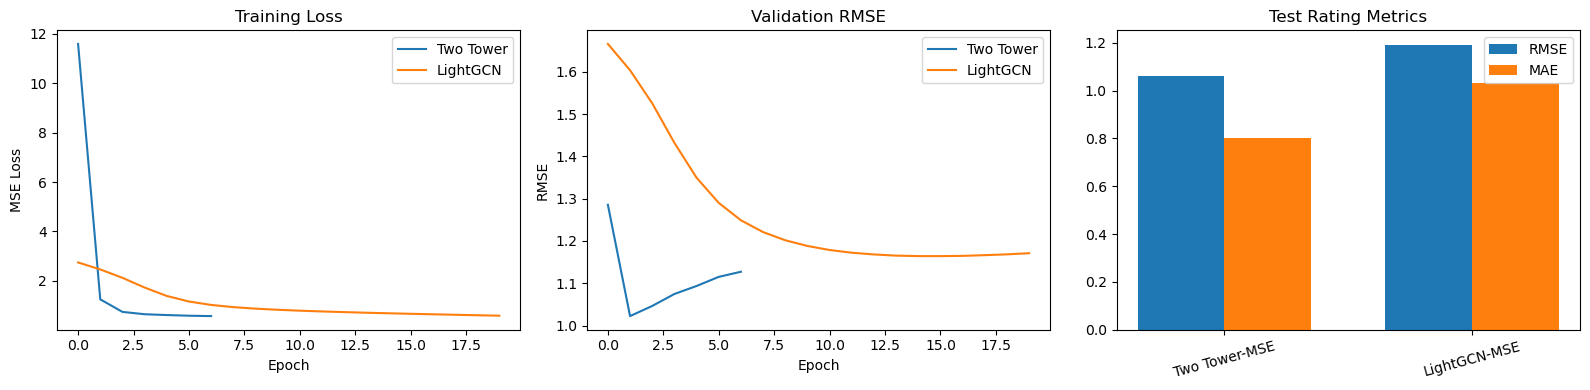

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

if two_tower_mse_history is not None:
    axes[0].plot(two_tower_mse_history['train_losses'], label='Two Tower')
if lightgcn_mse_history is not None:
    axes[0].plot(lightgcn_mse_history['train_losses'], label='LightGCN')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
if axes[0].lines:
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, 'Curves unavailable\n(checkpoints loaded)', ha='center', va='center')
    axes[0].set_xticks([])
    axes[0].set_yticks([])

if two_tower_mse_history is not None:
    axes[1].plot(two_tower_mse_history['val_rmses'], label='Two Tower')
if lightgcn_mse_history is not None:
    axes[1].plot(lightgcn_mse_history['val_rmses'], label='LightGCN')
axes[1].set_title('Validation RMSE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RMSE')
if axes[1].lines:
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'Curves unavailable\n(checkpoints loaded)', ha='center', va='center')
    axes[1].set_xticks([])
    axes[1].set_yticks([])

rating_plot_df = rating_summary_df.copy()
x = np.arange(len(rating_plot_df))
width = 0.35
axes[2].bar(x - width / 2, rating_plot_df['Test RMSE'], width=width, label='RMSE')
axes[2].bar(x + width / 2, rating_plot_df['Test MAE'], width=width, label='MAE')
axes[2].set_title('Test Rating Metrics')
axes[2].set_xticks(x)
axes[2].set_xticklabels(rating_plot_df['Model'], rotation=15)
axes[2].legend()

plt.tight_layout()
plt.show()


<a id='section-5-baseline-ranking-models'></a>
#### 5. Baseline Ranking Models


<a id='section-51-ranking-utilities'></a>
##### 5.1 Ranking Utilities


In [50]:
def _score_two_tower_all_items(model, user_idx: int, all_items_tensor: torch.Tensor) -> torch.Tensor:
    user_tensor = torch.full((len(all_items_tensor),), int(user_idx), dtype=torch.long, device=device)
    return model(user_tensor, all_items_tensor)

def compute_ranking_metrics(model, eval_data, model_type='lightgcn', top_k=None, adj_mat=None, seen_items_map=None):
    if top_k is None:
        top_k = EXPERIMENT_CONFIG['ranking_top_k']
    if seen_items_map is None:
        seen_items_map = user_positive_items
    relevance_threshold = EXPERIMENT_CONFIG['relevance_threshold']
    model.eval()
    user_items = defaultdict(list)
    for _, row in eval_data.iterrows():
        user_items[int(row['user_idx'])].append({'item': int(row['item_idx']), 'rating': float(row['rating'])})

    ndcg_scores, recall_scores, precision_scores, mrr_scores = [], [], [], []
    all_items_tensor = torch.arange(n_items, device=device)

    with torch.no_grad():
        user_emb = item_emb = None
        if model_type == 'lightgcn':
            user_emb, item_emb = model.computer(adj_mat)
        for user_idx, items_data in user_items.items():
            relevant_items = {d['item'] for d in items_data if d['rating'] >= relevance_threshold}
            if not relevant_items:
                continue
            if model_type == 'lightgcn':
                raw_scores = (user_emb[user_idx].unsqueeze(0) * item_emb).sum(dim=1)
                users_batch = torch.full((n_items,), int(user_idx), dtype=torch.long, device=device)
                scores = model._apply_rating_head(raw_scores, users_batch, all_items_tensor, apply_range=True)
            elif model_type == 'two_tower':
                scores = _score_two_tower_all_items(model, user_idx, all_items_tensor)
            else:
                raise ValueError(f'Unsupported model_type: {model_type}')
            seen_items = list(seen_items_map.get(user_idx, set()))
            if seen_items:
                scores = scores.clone()
                scores[seen_items] = -1e9
            _, top_items = torch.topk(scores, top_k)
            top_items = top_items.cpu().numpy()
            hits = [1 if item in relevant_items else 0 for item in top_items]
            dcg = sum(hits[i] / np.log2(i + 2) for i in range(len(hits)))
            idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant_items), top_k)))
            ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
            recall_scores.append(sum(hits) / len(relevant_items))
            precision_scores.append(sum(hits) / top_k)
            reciprocal_rank = 0.0
            for rank, item in enumerate(top_items, start=1):
                if item in relevant_items:
                    reciprocal_rank = 1.0 / rank
                    break
            mrr_scores.append(reciprocal_rank)
    return {
        'NDCG@10': float(np.mean(ndcg_scores)) if ndcg_scores else 0.0,
        'Recall@10': float(np.mean(recall_scores)) if recall_scores else 0.0,
        'Precision@10': float(np.mean(precision_scores)) if precision_scores else 0.0,
        'MRR': float(np.mean(mrr_scores)) if mrr_scores else 0.0,
        'num_users': len(ndcg_scores),
    }

def train_two_tower_bpr_with_val(model, train_df, val_df, save_path):
    optimizer = torch.optim.Adam(model.parameters(), lr=EXPERIMENT_CONFIG['lr'])
    train_dataset = BPRDataset(train_df, user_positive_items, n_items)
    train_loader = DataLoader(train_dataset, batch_size=EXPERIMENT_CONFIG['batch_size'], shuffle=True)
    best_val_ndcg = float('-inf')
    patience_counter = 0
    history = {'train_losses': [], 'val_ndcgs': [], 'val_recalls': []}
    for epoch in range(EXPERIMENT_CONFIG['bpr_epochs']):
        train_loss, _, _ = train_two_tower_bpr_epoch(
            model,
            train_loader,
            optimizer,
            device,
            reg_weight=EXPERIMENT_CONFIG['reg_weight'],
        )
        val_metrics = compute_ranking_metrics(model, val_df, model_type='two_tower', top_k=EXPERIMENT_CONFIG['ranking_top_k'])
        history['train_losses'].append(train_loss)
        history['val_ndcgs'].append(val_metrics['NDCG@10'])
        history['val_recalls'].append(val_metrics['Recall@10'])
        print(f"Epoch {epoch + 1:02d} | Train Loss: {train_loss:.4f} | Val NDCG@10: {val_metrics['NDCG@10']:.4f} | Val Recall@10: {val_metrics['Recall@10']:.4f}")
        if val_metrics['NDCG@10'] > best_val_ndcg:
            best_val_ndcg = val_metrics['NDCG@10']
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= EXPERIMENT_CONFIG['bpr_patience']:
                print('Early stopping triggered.')
                break
    return history

def train_lightgcn_bpr_with_val(model, train_df, val_df, adj_mat, save_path):
    optimizer = torch.optim.Adam(model.parameters(), lr=EXPERIMENT_CONFIG['lr'])
    best_val_ndcg = float('-inf')
    patience_counter = 0
    history = {'train_losses': [], 'val_ndcgs': [], 'val_recalls': []}
    for epoch in range(EXPERIMENT_CONFIG['bpr_epochs']):
        train_loss = train_lightgcn_bpr_epoch(
            model,
            adj_mat,
            train_df,
            user_positive_items,
            n_items,
            optimizer,
            device,
            reg_weight=EXPERIMENT_CONFIG['reg_weight'],
            batch_size=EXPERIMENT_CONFIG['batch_size'],
        )
        val_metrics = compute_ranking_metrics(model, val_df, model_type='lightgcn', top_k=EXPERIMENT_CONFIG['ranking_top_k'], adj_mat=adj_mat)
        history['train_losses'].append(train_loss)
        history['val_ndcgs'].append(val_metrics['NDCG@10'])
        history['val_recalls'].append(val_metrics['Recall@10'])
        print(f"Epoch {epoch + 1:02d} | Train Loss: {train_loss:.4f} | Val NDCG@10: {val_metrics['NDCG@10']:.4f} | Val Recall@10: {val_metrics['Recall@10']:.4f}")
        if val_metrics['NDCG@10'] > best_val_ndcg:
            best_val_ndcg = val_metrics['NDCG@10']
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= EXPERIMENT_CONFIG['bpr_patience']:
                print('Early stopping triggered.')
                break
    return history


<a id='section-52-two-tower-with-bpr'></a>
##### 5.2 Two Tower with BPR


- Path: keep the Two Tower encoder, replace MSE with pairwise BPR training
- Strengths: lightweight ranking baseline
- Weaknesses: no graph propagation

[[Back to Contents]](#table-of-contents)


In [51]:
set_global_seed(SEED)
print('Reseeded global RNG state for this section.')

two_tower_bpr_model = TwoTowerMLP(
    n_users,
    n_items,
    embedding_dim=EXPERIMENT_CONFIG['embedding_dim'],
    hidden_dims=EXPERIMENT_CONFIG['two_tower_hidden_dims'],
).to(device)

if MODEL_PATHS['two_tower_bpr'].exists() and not EXPERIMENT_CONFIG['force_retrain']:
    two_tower_bpr_model.load_state_dict(torch.load(MODEL_PATHS['two_tower_bpr'], map_location=device))
    two_tower_bpr_history = None
    print('Loaded existing Two Tower BPR checkpoint.')
else:
    two_tower_bpr_history = train_two_tower_bpr_with_val(
        two_tower_bpr_model,
        train_data,
        val_data,
        MODEL_PATHS['two_tower_bpr'],
    )
    two_tower_bpr_model.load_state_dict(torch.load(MODEL_PATHS['two_tower_bpr'], map_location=device))

two_tower_bpr_metrics = compute_ranking_metrics(
    two_tower_bpr_model,
    test_data,
    model_type='two_tower',
    top_k=EXPERIMENT_CONFIG['ranking_top_k'],
)
two_tower_bpr_metrics


Reseeded global RNG state for this section.
Epoch 01 | Train Loss: 0.6436 | Val NDCG@10: 0.0241 | Val Recall@10: 0.0424
Epoch 02 | Train Loss: 0.5303 | Val NDCG@10: 0.0216 | Val Recall@10: 0.0406
Epoch 03 | Train Loss: 0.5127 | Val NDCG@10: 0.0238 | Val Recall@10: 0.0416
Epoch 04 | Train Loss: 0.5037 | Val NDCG@10: 0.0232 | Val Recall@10: 0.0404
Epoch 05 | Train Loss: 0.4985 | Val NDCG@10: 0.0234 | Val Recall@10: 0.0418
Epoch 06 | Train Loss: 0.4935 | Val NDCG@10: 0.0232 | Val Recall@10: 0.0401
Early stopping triggered.


{'NDCG@10': 0.023901246072590265,
 'Recall@10': 0.04329910834909484,
 'Precision@10': 0.004329910834909485,
 'MRR': 0.01802907193679958,
 'num_users': 14804}

<a id='section-53-lightgcn-with-bpr'></a>
##### 5.3 LightGCN with BPR


- Path: LightGCN propagation + BPR ranking loss
- Strengths: strongest collaborative ranking baseline in earlier experiments
- Weaknesses: graph-based training cost is higher

[[Back to Contents]](#table-of-contents)


In [52]:
set_global_seed(SEED)
print('Reseeded global RNG state for this section.')

lightgcn_bpr_model = LightGCN(
    n_users,
    n_items,
    embedding_dim=EXPERIMENT_CONFIG['embedding_dim'],
    n_layers=EXPERIMENT_CONFIG['lightgcn_layers'],
).to(device)

if MODEL_PATHS['lightgcn_bpr'].exists() and not EXPERIMENT_CONFIG['force_retrain']:
    lightgcn_bpr_model.load_state_dict(torch.load(MODEL_PATHS['lightgcn_bpr'], map_location=device))
    lightgcn_bpr_history = None
    print('Loaded existing LightGCN BPR checkpoint.')
else:
    lightgcn_bpr_history = train_lightgcn_bpr_with_val(
        lightgcn_bpr_model,
        train_data,
        val_data,
        norm_adj_tensor,
        MODEL_PATHS['lightgcn_bpr'],
    )
    lightgcn_bpr_model.load_state_dict(torch.load(MODEL_PATHS['lightgcn_bpr'], map_location=device))

lightgcn_bpr_metrics = compute_ranking_metrics(
    lightgcn_bpr_model,
    test_data,
    model_type='lightgcn',
    top_k=EXPERIMENT_CONFIG['ranking_top_k'],
    adj_mat=norm_adj_tensor,
)
base_lightgcn_bpr_metrics = lightgcn_bpr_metrics
lightgcn_bpr_metrics


Reseeded global RNG state for this section.
Epoch 01 | Train Loss: 0.6701 | Val NDCG@10: 0.0016 | Val Recall@10: 0.0032
Epoch 02 | Train Loss: 0.6577 | Val NDCG@10: 0.0090 | Val Recall@10: 0.0154
Epoch 03 | Train Loss: 0.6362 | Val NDCG@10: 0.0196 | Val Recall@10: 0.0359
Epoch 04 | Train Loss: 0.6008 | Val NDCG@10: 0.0254 | Val Recall@10: 0.0465
Epoch 05 | Train Loss: 0.5497 | Val NDCG@10: 0.0280 | Val Recall@10: 0.0518
Epoch 06 | Train Loss: 0.4910 | Val NDCG@10: 0.0299 | Val Recall@10: 0.0553
Epoch 07 | Train Loss: 0.4329 | Val NDCG@10: 0.0309 | Val Recall@10: 0.0575
Epoch 08 | Train Loss: 0.3793 | Val NDCG@10: 0.0321 | Val Recall@10: 0.0597
Epoch 09 | Train Loss: 0.3339 | Val NDCG@10: 0.0326 | Val Recall@10: 0.0606
Epoch 10 | Train Loss: 0.2943 | Val NDCG@10: 0.0335 | Val Recall@10: 0.0621
Epoch 11 | Train Loss: 0.2620 | Val NDCG@10: 0.0343 | Val Recall@10: 0.0635
Epoch 12 | Train Loss: 0.2338 | Val NDCG@10: 0.0350 | Val Recall@10: 0.0647
Epoch 13 | Train Loss: 0.2101 | Val NDCG@10:

{'NDCG@10': 0.03632432610454478,
 'Recall@10': 0.06559038097811402,
 'Precision@10': 0.006559038097811403,
 'MRR': 0.02748879003100835,
 'num_users': 14804}

<a id='section-54-baseline-ranking-comparison'></a>
##### 5.4 Baseline Ranking Comparison


##### 5.5 Baseline Ranking Curves


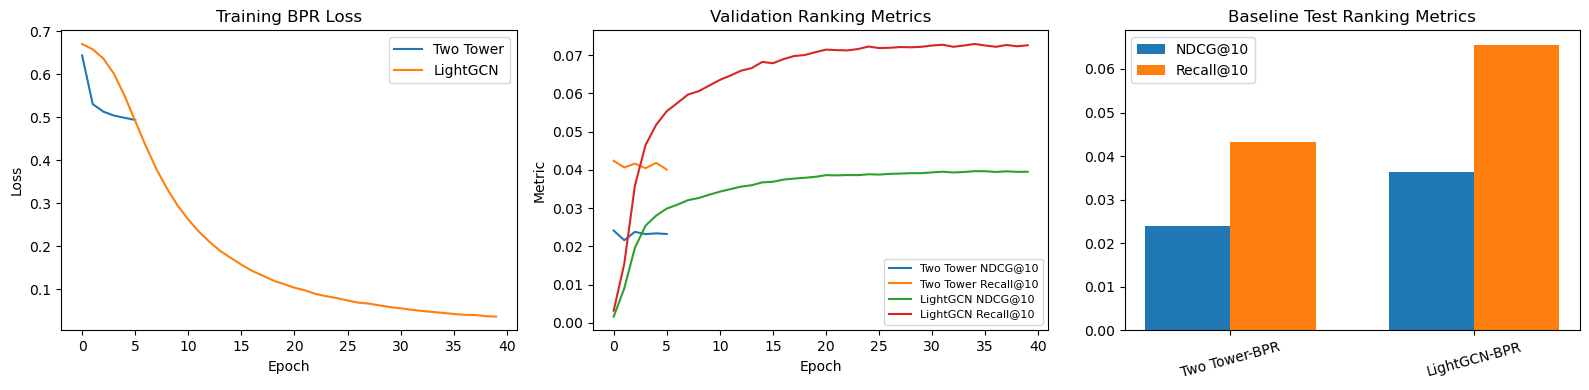

In [53]:
baseline_ranking_plot_df = pd.DataFrame([
    {'Model': 'Two Tower-BPR', **two_tower_bpr_metrics},
    {'Model': 'LightGCN-BPR', **lightgcn_bpr_metrics},
])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

if two_tower_bpr_history is not None:
    axes[0].plot(two_tower_bpr_history['train_losses'], label='Two Tower')
if lightgcn_bpr_history is not None:
    axes[0].plot(lightgcn_bpr_history['train_losses'], label='LightGCN')
axes[0].set_title('Training BPR Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
if axes[0].lines:
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, 'Curves unavailable\n(checkpoints loaded)', ha='center', va='center')
    axes[0].set_xticks([])
    axes[0].set_yticks([])

if two_tower_bpr_history is not None:
    axes[1].plot(two_tower_bpr_history['val_ndcgs'], label='Two Tower NDCG@10')
    axes[1].plot(two_tower_bpr_history['val_recalls'], label='Two Tower Recall@10')
if lightgcn_bpr_history is not None:
    axes[1].plot(lightgcn_bpr_history['val_ndcgs'], label='LightGCN NDCG@10')
    axes[1].plot(lightgcn_bpr_history['val_recalls'], label='LightGCN Recall@10')
axes[1].set_title('Validation Ranking Metrics')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Metric')
if axes[1].lines:
    axes[1].legend(fontsize=8)
else:
    axes[1].text(0.5, 0.5, 'Curves unavailable\n(checkpoints loaded)', ha='center', va='center')
    axes[1].set_xticks([])
    axes[1].set_yticks([])

x = np.arange(len(baseline_ranking_plot_df))
width = 0.35
axes[2].bar(x - width / 2, baseline_ranking_plot_df['NDCG@10'], width=width, label='NDCG@10')
axes[2].bar(x + width / 2, baseline_ranking_plot_df['Recall@10'], width=width, label='Recall@10')
axes[2].set_title('Baseline Test Ranking Metrics')
axes[2].set_xticks(x)
axes[2].set_xticklabels(baseline_ranking_plot_df['Model'], rotation=15)
axes[2].legend()

plt.tight_layout()
plt.show()


In [54]:
lightgcn_mse_ranking_metrics = compute_ranking_metrics(
    lightgcn_mse_model,
    test_data,
    model_type='lightgcn',
    top_k=EXPERIMENT_CONFIG['ranking_top_k'],
    adj_mat=norm_adj_tensor,
)
two_tower_mse_ranking_metrics = compute_ranking_metrics(
    two_tower_mse_model,
    test_data,
    model_type='two_tower',
    top_k=EXPERIMENT_CONFIG['ranking_top_k'],
)

baseline_ranking_df = pd.DataFrame([
    {'Model': 'Two Tower-MSE', **two_tower_mse_ranking_metrics},
    {'Model': 'LightGCN-MSE', **lightgcn_mse_ranking_metrics},
    {'Model': 'Two Tower-BPR', **two_tower_bpr_metrics},
    {'Model': 'LightGCN-BPR', **lightgcn_bpr_metrics},
])
baseline_ranking_df


,Model,NDCG@10,Recall@10,Precision@10,MRR,num_users
0,Two Tower-MSE,0.000676,0.001554,0.000155,0.000417,14804
1,LightGCN-MSE,0.023970,0.044988,0.004499,0.017608,14804
2,Two Tower-BPR,0.023901,0.043299,0.004330,0.018029,14804
3,LightGCN-BPR,0.036324,0.065590,0.006559,0.027489,14804


<a id='section-6-ranking-extensions'></a>
#### 6. Ranking Extensions


<a id='section-61-residual-linear-reranking'></a>
##### 6.1 Residual Linear Reranking


- Path: keep LightGCN-BPR as the backbone and learn a small score correction
- Features: base collaborative score + item quality score
- Target: improve ranking without rebuilding the base model


In [55]:
set_global_seed(SEED)
print('Reseeded global RNG state for ranking extensions.')


def print_section(title: str) -> None:
    print('\n' + '=' * 80)
    print(title)
    print('=' * 80)


def print_subsection(title: str) -> None:
    print('\n' + title)
    print('-' * len(title))


def evaluate_lightgcn_ranking_with_adj(model, adj_mat, eval_data, top_k=10):
    return compute_ranking_metrics(
        model,
        eval_data,
        model_type='lightgcn',
        top_k=top_k,
        adj_mat=adj_mat,
    )

def compute_item_quality_scores(train_df, prior_weight=10.0):
    """Compute Bayesian-smoothed item quality scores using training ratings only."""
    item_stats = train_df.groupby('item_idx')['rating'].agg(['mean', 'count']).reset_index()
    global_mean = train_df['rating'].mean()
    item_stats['bayesian_mean'] = (
        item_stats['count'] * item_stats['mean'] + prior_weight * global_mean
    ) / (item_stats['count'] + prior_weight)
    item_stats['quality_score'] = ((item_stats['bayesian_mean'] - 1.0) / 4.0).clip(0.0, 1.0)
    quality_map = dict(zip(item_stats['item_idx'], item_stats['quality_score']))
    mean_rating_map = dict(zip(item_stats['item_idx'], item_stats['bayesian_mean']))
    return quality_map, mean_rating_map, item_stats


class LinearFusionReranker(nn.Module):
    """Learned residual adjustment from CF and quality features."""

    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)

    def forward(self, features):
        return self.linear(features).squeeze(-1)


class SmallMLPReranker(nn.Module):
    """Small MLP residual reranker."""

    def __init__(self, hidden_dim=8):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, features):
        return self.network(features).squeeze(-1)


def split_reranker_fit_and_tune_data(val_df, tune_fraction=0.2, random_seed=42):
    """Split validation users so reranker fitting and beta tuning are separated."""
    unique_users = np.array(sorted(val_df['user_idx'].unique()))
    rng = np.random.default_rng(random_seed)
    shuffled_users = unique_users.copy()
    rng.shuffle(shuffled_users)
    num_tune_users = max(1, int(len(shuffled_users) * tune_fraction))
    tune_users = set(shuffled_users[:num_tune_users].tolist())
    tune_df = val_df[val_df['user_idx'].isin(tune_users)].copy()
    fit_df = val_df[~val_df['user_idx'].isin(tune_users)].copy()
    return fit_df, tune_df


def build_reranker_training_data(base_model, adj_mat, fit_data, quality_map,
                                 candidate_k=100, negatives_per_user=20):
    """Build reranker training examples from held-out validation users."""
    base_model.eval()
    quality_default = float(np.mean(list(quality_map.values()))) if quality_map else 0.5

    user_items = defaultdict(list)
    for _, row in fit_data.iterrows():
        user_items[row['user_idx']].append({'item': row['item_idx'], 'rating': row['rating']})

    feature_rows = []
    labels = []

    with torch.no_grad():
        user_emb, item_emb = base_model.computer(adj_mat)
        all_items_tensor = torch.arange(n_items, device=device)

        for user_idx, items_data in user_items.items():
            relevant_items = {int(item['item']) for item in items_data if item['rating'] >= 4.0}
            if not relevant_items:
                continue

            users_batch = torch.full((n_items,), int(user_idx), dtype=torch.long, device=device)
            scores = (user_emb[user_idx].unsqueeze(0) * item_emb).sum(dim=1)
            scores = base_model._apply_rating_head(scores, users_batch, all_items_tensor, apply_range=True)

            seen_items = list(user_positive_items.get(user_idx, set()))
            if seen_items:
                scores = scores.clone()
                scores[seen_items] = -1e9

            candidate_size = min(candidate_k, n_items)
            _, top_items = torch.topk(scores, candidate_size)
            candidate_items = top_items.cpu().numpy().tolist()
            candidate_set = set(candidate_items) | relevant_items
            negative_candidates = [item for item in candidate_set if item not in relevant_items]
            if not negative_candidates:
                continue

            if len(negative_candidates) > negatives_per_user:
                sampled_negatives = np.random.choice(negative_candidates, size=negatives_per_user, replace=False).tolist()
            else:
                sampled_negatives = negative_candidates

            for pos_item in relevant_items:
                feature_rows.append([
                    float(scores[pos_item].item()),
                    float(quality_map.get(pos_item, quality_default)),
                ])
                labels.append(1.0)

            for neg_item in sampled_negatives:
                feature_rows.append([
                    float(scores[int(neg_item)].item()),
                    float(quality_map.get(int(neg_item), quality_default)),
                ])
                labels.append(0.0)

    if not feature_rows:
        raise ValueError('No reranker training examples were created from reranker_fit_data.')

    features = np.asarray(feature_rows, dtype=np.float32)
    labels = np.asarray(labels, dtype=np.float32)
    feature_mean = features.mean(axis=0)
    feature_std = features.std(axis=0)
    feature_std[feature_std < 1e-6] = 1.0
    normalized_features = (features - feature_mean) / feature_std

    feature_tensor = torch.tensor(normalized_features, dtype=torch.float32, device=device)
    label_tensor = torch.tensor(labels, dtype=torch.float32, device=device)
    feature_stats = {'mean': feature_mean, 'std': feature_std, 'candidate_k': candidate_k}
    return feature_tensor, label_tensor, feature_stats


def train_reranker_model(model, features, labels, model_name, num_epochs=60, lr=0.01, weight_decay=1e-4):
    """Train a lightweight reranker on validation-derived examples."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    pos_count = float(labels.sum().item())
    neg_count = float(len(labels) - pos_count)
    pos_weight_value = neg_count / max(pos_count, 1.0)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_value], device=features.device))

    history = []
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(features)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).float()
            accuracy = float((predictions == labels).float().mean().item())
        history.append({'epoch': epoch + 1, 'loss': float(loss.item()), 'accuracy': accuracy})

        if (epoch + 1) % 10 == 0 or epoch == 0 or epoch + 1 == num_epochs:
            print(f"{model_name} | Epoch {epoch + 1:02d}/{num_epochs} | Loss: {loss.item():.4f} | Accuracy: {accuracy:.4f}")

    return pd.DataFrame(history)


def compute_residual_reranking_metrics(base_model, reranker_model, adj_mat, eval_data,
                                       quality_map, feature_stats, beta=0.1, top_k=10):
    """Evaluate residual reranking: final_score = base_score + beta * reranker_delta."""
    base_model.eval()
    reranker_model.eval()

    quality_default = float(np.mean(list(quality_map.values()))) if quality_map else 0.5
    feature_mean = torch.tensor(feature_stats['mean'], dtype=torch.float32, device=device)
    feature_std = torch.tensor(feature_stats['std'], dtype=torch.float32, device=device)
    candidate_k = int(feature_stats.get('candidate_k', 100))

    user_items = defaultdict(list)
    for _, row in eval_data.iterrows():
        user_items[row['user_idx']].append({'item': row['item_idx'], 'rating': row['rating']})

    ndcg_scores = []
    recall_scores = []
    precision_scores = []
    mrr_scores = []
    quality_ndcg_scores = []
    avg_quality_scores = []
    avg_train_ratings = []
    bad_item_rates = []
    recommended_catalog = set()

    with torch.no_grad():
        user_emb, item_emb = base_model.computer(adj_mat)
        all_items_tensor = torch.arange(n_items, device=device)

        for user_idx, items_data in user_items.items():
            relevant_items = {int(item['item']) for item in items_data if item['rating'] >= 4.0}
            if not relevant_items:
                continue

            users_batch = torch.full((n_items,), int(user_idx), dtype=torch.long, device=device)
            scores = (user_emb[user_idx].unsqueeze(0) * item_emb).sum(dim=1)
            scores = base_model._apply_rating_head(scores, users_batch, all_items_tensor, apply_range=True)

            seen_items = list(user_positive_items.get(user_idx, set()))
            if seen_items:
                scores = scores.clone()
                scores[seen_items] = -1e9

            candidate_size = min(candidate_k, n_items)
            candidate_scores, candidate_items = torch.topk(scores, candidate_size)
            candidate_quality = torch.tensor(
                [quality_map.get(int(item), quality_default) for item in candidate_items.cpu().numpy()],
                dtype=torch.float32,
                device=device,
            )
            reranker_features = torch.stack([candidate_scores, candidate_quality], dim=1)
            reranker_features = (reranker_features - feature_mean) / feature_std
            reranker_delta = reranker_model(reranker_features)
            final_scores = candidate_scores + beta * reranker_delta

            rerank_k = min(top_k, candidate_items.shape[0])
            top_indices = torch.topk(final_scores, rerank_k).indices
            top_items = candidate_items[top_indices].cpu().numpy()
            recommended_catalog.update(int(item) for item in top_items)

            hits = [1 if item in relevant_items else 0 for item in top_items]
            dcg = sum(hits[idx] / np.log2(idx + 2) for idx in range(len(hits)))
            idcg = sum(1.0 / np.log2(idx + 2) for idx in range(min(len(relevant_items), top_k)))
            ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
            recall_scores.append(sum(hits) / len(relevant_items))
            precision_scores.append(sum(hits) / top_k)

            reciprocal_rank = 0.0
            for rank, item in enumerate(top_items, start=1):
                if item in relevant_items:
                    reciprocal_rank = 1.0 / rank
                    break
            mrr_scores.append(reciprocal_rank)

            recommended_quality = [quality_map.get(int(item), quality_default) for item in top_items]
            recommended_ratings = [item_train_mean_rating_map.get(int(item), train_data['rating'].mean()) for item in top_items]
            avg_quality_scores.append(float(np.mean(recommended_quality)))
            avg_train_ratings.append(float(np.mean(recommended_ratings)))
            bad_item_rates.append(sum(rating <= 3.5 for rating in recommended_ratings) / top_k)

            quality_hits = [quality_map.get(int(item), quality_default) if item in relevant_items else 0.0 for item in top_items]
            quality_dcg = sum(quality_hits[idx] / np.log2(idx + 2) for idx in range(len(quality_hits)))
            ideal_quality = sorted([quality_map.get(int(item), quality_default) for item in relevant_items], reverse=True)[:top_k]
            quality_idcg = sum(score / np.log2(idx + 2) for idx, score in enumerate(ideal_quality))
            quality_ndcg_scores.append(quality_dcg / quality_idcg if quality_idcg > 0 else 0.0)

    return {
        'NDCG@10': float(np.mean(ndcg_scores)) if ndcg_scores else 0.0,
        'Recall@10': float(np.mean(recall_scores)) if recall_scores else 0.0,
        'Precision@10': float(np.mean(precision_scores)) if precision_scores else 0.0,
        'MRR': float(np.mean(mrr_scores)) if mrr_scores else 0.0,
        'AvgQuality@10': float(np.mean(avg_quality_scores)) if avg_quality_scores else 0.0,
        'AvgTrainRating@10': float(np.mean(avg_train_ratings)) if avg_train_ratings else 0.0,
        'BadItemRate@10': float(np.mean(bad_item_rates)) if bad_item_rates else 0.0,
        'QualityNDCG@10': float(np.mean(quality_ndcg_scores)) if quality_ndcg_scores else 0.0,
        'Coverage@10': len(recommended_catalog) / n_items if n_items > 0 else 0.0,
        'num_users': len(ndcg_scores),
    }


def select_best_residual_beta(base_model, reranker_model, adj_mat, tune_data, quality_map,
                              feature_stats, model_name, beta_values, top_k=10):
    """Choose a residual strength on held-out validation users."""
    rows = []
    for beta in beta_values:
        metrics = compute_residual_reranking_metrics(
            base_model,
            reranker_model,
            adj_mat,
            tune_data,
            quality_map,
            feature_stats,
            beta=beta,
            top_k=top_k,
        )
        rows.append({'Model': model_name, 'beta': beta, **metrics})
        print(
            f"{model_name} | beta={beta:.2f} | NDCG@10={metrics['NDCG@10']:.4f} | "
            f"Recall@10={metrics['Recall@10']:.4f} | AvgQuality@10={metrics['AvgQuality@10']:.4f}"
        )

    beta_df = pd.DataFrame(rows)
    best_row = beta_df.sort_values(['NDCG@10', 'Recall@10', 'AvgQuality@10'], ascending=[False, False, False]).iloc[0]
    return beta_df, float(best_row['beta'])


item_quality_score_map, item_train_mean_rating_map, item_quality_stats = compute_item_quality_scores(train_data)
reranking_base_model = LightGCN(n_users, n_items, embedding_dim=64, n_layers=3).to(device)
reranking_base_model.load_state_dict(torch.load(MODEL_PATHS['lightgcn_bpr'], map_location=device))

reranker_fit_data, reranker_tune_data = split_reranker_fit_and_tune_data(val_data, tune_fraction=0.2, random_seed=42)
reranking_candidate_k = 100
reranking_fit_features, reranking_fit_labels, reranking_feature_stats = build_reranker_training_data(
    reranking_base_model,
    norm_adj_tensor,
    reranker_fit_data,
    item_quality_score_map,
    candidate_k=reranking_candidate_k,
    negatives_per_user=20,
)

print_section('Residual Re-ranking Setup')
print(f"Training items with quality scores: {len(item_quality_score_map)}")
print(f"Average Bayesian-smoothed rating: {item_quality_stats['bayesian_mean'].mean():.4f}")
print(f"Average normalized quality score: {item_quality_stats['quality_score'].mean():.4f}")
print(f"Reranker fit users: {reranker_fit_data['user_idx'].nunique()}")
print(f"Reranker tune users: {reranker_tune_data['user_idx'].nunique()}")
print(f"Reranker training examples: {len(reranking_fit_labels)}")
print(f"Positive labels: {int(reranking_fit_labels.sum().item())}")
print(f"Candidate pool size for reranking: top-{reranking_candidate_k}")

Reseeded global RNG state for ranking extensions.

Residual Re-ranking Setup
Training items with quality scores: 8934
Average Bayesian-smoothed rating: 4.3942
Average normalized quality score: 0.8485
Reranker fit users: 14000
Reranker tune users: 3500
Reranker training examples: 251076
Positive labels: 11956
Candidate pool size for reranking: top-100



Training the Residual Linear Reranker
Residual Linear | Epoch 01/60 | Loss: 1.2474 | Accuracy: 0.7283
Residual Linear | Epoch 10/60 | Loss: 1.1675 | Accuracy: 0.7029
Residual Linear | Epoch 20/60 | Loss: 1.1022 | Accuracy: 0.7213
Residual Linear | Epoch 30/60 | Loss: 1.0522 | Accuracy: 0.7686
Residual Linear | Epoch 40/60 | Loss: 1.0161 | Accuracy: 0.8084
Residual Linear | Epoch 50/60 | Loss: 0.9910 | Accuracy: 0.8302
Residual Linear | Epoch 60/60 | Loss: 0.9738 | Accuracy: 0.8367


,epoch,loss,accuracy
55,56,0.979927,0.835249
56,57,0.978314,0.835596
57,58,0.976761,0.836117
58,59,0.975266,0.836420
59,60,0.973829,0.836671


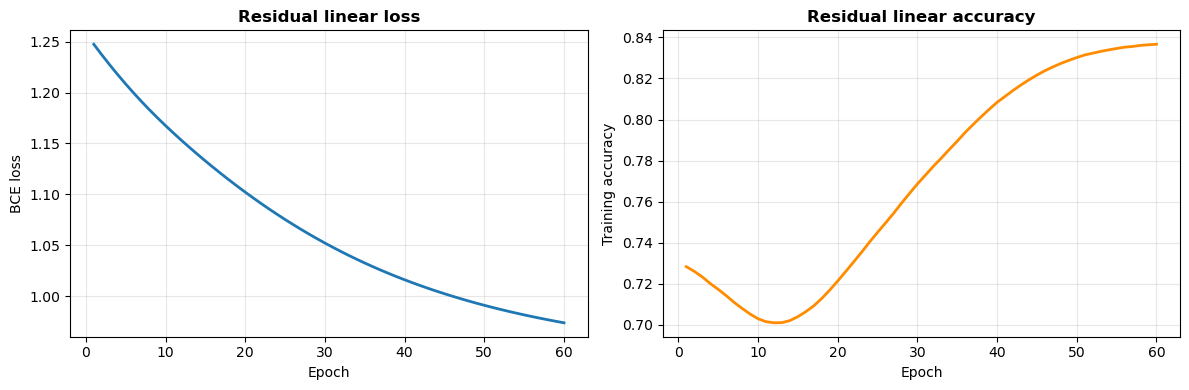

In [56]:
print_section('Training the Residual Linear Reranker')

linear_reranker = LinearFusionReranker().to(device)
linear_reranker_history = train_reranker_model(
    linear_reranker,
    reranking_fit_features,
    reranking_fit_labels,
    model_name='Residual Linear',
    num_epochs=60,
    lr=0.01,
    weight_decay=1e-4,
)

display(linear_reranker_history.tail())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(linear_reranker_history['epoch'], linear_reranker_history['loss'], linewidth=2)
ax[0].set_title('Residual linear loss', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('BCE loss')
ax[0].grid(True, alpha=0.3)
ax[1].plot(linear_reranker_history['epoch'], linear_reranker_history['accuracy'], linewidth=2, color='darkorange')
ax[1].set_title('Residual linear accuracy', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Training accuracy')
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<a id='section-62-residual-mlp-reranking'></a>
##### 6.2 Residual MLP Reranking

- Path: keep the residual reranking setup and replace the linear correction with a small MLP
- Source: copied from the RS residual small MLP reranker
- Target: test whether nonlinear residual score correction improves ranking


Training the Residual Small MLP Reranker
Residual Small MLP | Epoch 01/60 | Loss: 1.2920 | Accuracy: 0.4019
Residual Small MLP | Epoch 10/60 | Loss: 1.1631 | Accuracy: 0.4780
Residual Small MLP | Epoch 20/60 | Loss: 1.0629 | Accuracy: 0.6328
Residual Small MLP | Epoch 30/60 | Loss: 0.9949 | Accuracy: 0.7379
Residual Small MLP | Epoch 40/60 | Loss: 0.9487 | Accuracy: 0.8008
Residual Small MLP | Epoch 50/60 | Loss: 0.9190 | Accuracy: 0.8405
Residual Small MLP | Epoch 60/60 | Loss: 0.9007 | Accuracy: 0.8660


,epoch,loss,accuracy
55,56,0.906985,0.857039
56,57,0.905309,0.859449
57,58,0.903713,0.861775
58,59,0.902192,0.863886
59,60,0.900741,0.865973


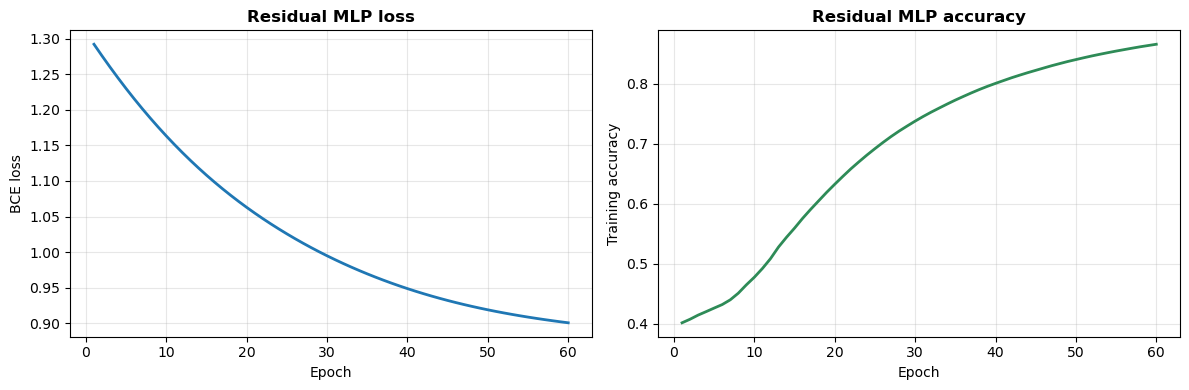

In [57]:
print_section('Training the Residual Small MLP Reranker')

mlp_reranker = SmallMLPReranker(hidden_dim=8).to(device)
mlp_reranker_history = train_reranker_model(
    mlp_reranker,
    reranking_fit_features,
    reranking_fit_labels,
    model_name='Residual Small MLP',
    num_epochs=60,
    lr=0.005,
    weight_decay=1e-4,
)

display(mlp_reranker_history.tail())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(mlp_reranker_history['epoch'], mlp_reranker_history['loss'], linewidth=2)
ax[0].set_title('Residual MLP loss', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('BCE loss')
ax[0].grid(True, alpha=0.3)
ax[1].plot(mlp_reranker_history['epoch'], mlp_reranker_history['accuracy'], linewidth=2, color='seagreen')
ax[1].set_title('Residual MLP accuracy', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Training accuracy')
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Tuning and Evaluating Residual Learnable Re-ranking
Residual linear reranker | beta=0.01 | NDCG@10=0.0414 | Recall@10=0.0757 | AvgQuality@10=0.8698
Residual linear reranker | beta=0.05 | NDCG@10=0.0412 | Recall@10=0.0740 | AvgQuality@10=0.8674
Residual linear reranker | beta=0.10 | NDCG@10=0.0401 | Recall@10=0.0716 | AvgQuality@10=0.8640
Residual linear reranker | beta=0.20 | NDCG@10=0.0373 | Recall@10=0.0689 | AvgQuality@10=0.8552
Residual linear reranker | beta=0.50 | NDCG@10=0.0162 | Recall@10=0.0348 | AvgQuality@10=0.7742
Residual small MLP reranker | beta=0.01 | NDCG@10=0.0401 | Recall@10=0.0733 | AvgQuality@10=0.8718
Residual small MLP reranker | beta=0.05 | NDCG@10=0.0398 | Recall@10=0.0730 | AvgQuality@10=0.8753
Residual small MLP reranker | beta=0.10 | NDCG@10=0.0396 | Recall@10=0.0730 | AvgQuality@10=0.8790
Residual small MLP reranker | beta=0.20 | NDCG@10=0.0383 | Recall@10=0.0702 | AvgQuality@10=0.8862
Residual small MLP reranker | beta=0.50 | NDCG@10=0.0301 | Recall@10=0.

,Model,beta,NDCG@10,Recall@10,Precision@10,MRR,AvgQuality@10,AvgTrainRating@10,BadItemRate@10,QualityNDCG@10,Coverage@10,num_users
0,Residual linear reranker,0.01,0.041415,0.075690,0.007569,0.030994,0.869842,4.479367,0.002318,0.041415,0.251597,2933
1,Residual linear reranker,0.05,0.041195,0.073986,0.007399,0.031273,0.867440,4.469760,0.002830,0.041195,0.252463,2933
2,Residual linear reranker,0.10,0.040053,0.071599,0.007160,0.030509,0.863976,4.455904,0.003648,0.040053,0.253546,2933
3,Residual linear reranker,0.20,0.037339,0.068871,0.006887,0.027742,0.855184,4.420738,0.005557,0.037339,0.252679,2933
4,Residual linear reranker,0.50,0.016176,0.034777,0.003478,0.010575,0.774226,4.096905,0.021139,0.016176,0.191404,2933
5,Residual small MLP reranker,0.01,0.040144,0.073304,0.007330,0.030052,0.871797,4.487186,0.002114,0.040144,0.251164,2933
6,Residual small MLP reranker,0.05,0.039838,0.072963,0.007296,0.029765,0.875316,4.501265,0.001671,0.039838,0.249756,2933
7,Residual small MLP reranker,0.10,0.039604,0.072963,0.007296,0.029521,0.879007,4.516030,0.001227,0.039604,0.246942,2933
8,Residual small MLP reranker,0.20,0.038349,0.070235,0.007024,0.028680,0.886209,4.544836,0.000648,0.038349,0.240663,2933
9,Residual small MLP reranker,0.50,0.030083,0.058643,0.005864,0.021455,0.910370,4.641478,0.000000,0.030083,0.172242,2933


,Method,beta,NDCG@10,Recall@10,Precision@10,MRR,AvgQuality@10,AvgTrainRating@10,BadItemRate@10,QualityNDCG@10,Coverage@10,num_users
0,Baseline LightGCN-BPR,0.00,0.036324,0.065590,0.006559,0.027489,NaN,NaN,NaN,NaN,NaN,NaN
1,Residual linear reranker,0.01,0.036007,0.065050,0.006505,0.027230,0.869458,4.477833,0.002466,0.036007,0.454693,14804.0
2,Residual small MLP reranker,0.01,0.036503,0.065861,0.006586,0.027638,0.871356,4.485424,0.002276,0.036503,0.453069,14804.0


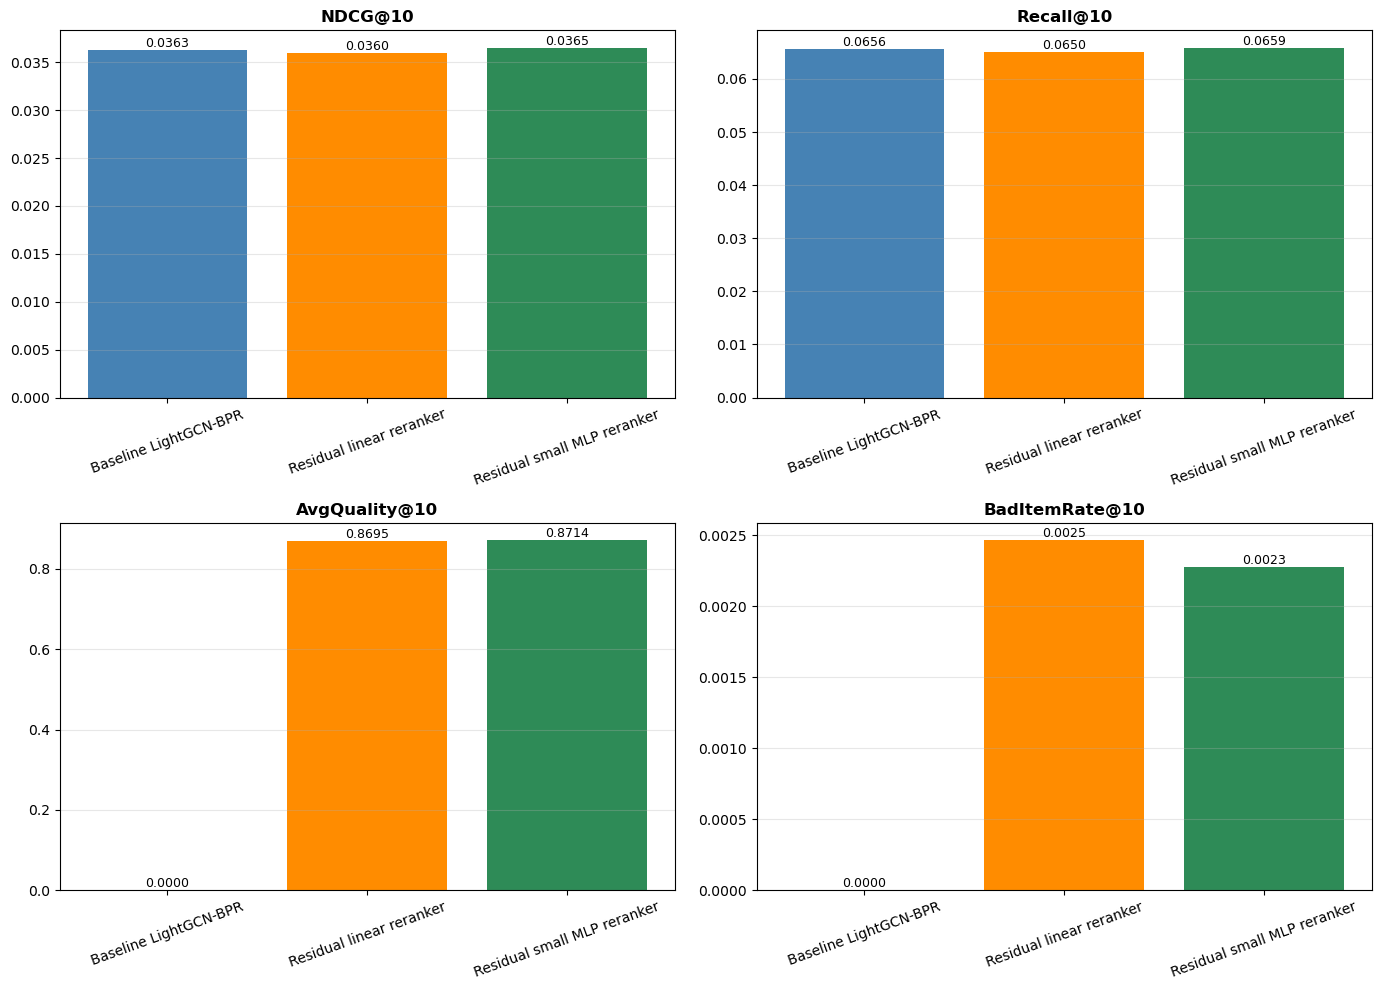


Best Residual Learnable Reranking Result
Linear best beta: 0.01
MLP best beta: 0.01
Best reranker on test: Residual small MLP reranker


In [58]:
if 'base_lightgcn_bpr_metrics' not in globals():
    print('base_lightgcn_bpr_metrics not found; rebuilding LightGCN-BPR baseline metrics...')
    _base_lightgcn_bpr_model = LightGCN(n_users, n_items, embedding_dim=64, n_layers=3).to(device)
    _base_lightgcn_bpr_model.load_state_dict(torch.load(MODEL_PATHS['lightgcn_bpr'], map_location=device))
    if 'evaluate_lightgcn_ranking_with_adj' in globals():
        base_lightgcn_bpr_metrics = evaluate_lightgcn_ranking_with_adj(
            _base_lightgcn_bpr_model,
            norm_adj_tensor,
            test_data,
            top_k=10,
        )
    else:
        base_lightgcn_bpr_metrics = compute_ranking_metrics(
            _base_lightgcn_bpr_model,
            test_data,
            model_type='lightgcn',
            top_k=10,
        )

print_section('Tuning and Evaluating Residual Learnable Re-ranking')

beta_values = [0.01, 0.05, 0.10, 0.20, 0.50]
linear_beta_df, linear_best_beta = select_best_residual_beta(
    reranking_base_model,
    linear_reranker,
    norm_adj_tensor,
    reranker_tune_data,
    item_quality_score_map,
    reranking_feature_stats,
    model_name='Residual linear reranker',
    beta_values=beta_values,
    top_k=10,
)
mlp_beta_df, mlp_best_beta = select_best_residual_beta(
    reranking_base_model,
    mlp_reranker,
    norm_adj_tensor,
    reranker_tune_data,
    item_quality_score_map,
    reranking_feature_stats,
    model_name='Residual small MLP reranker',
    beta_values=beta_values,
    top_k=10,
)

reranker_beta_tuning_df = pd.concat([linear_beta_df, mlp_beta_df], ignore_index=True)
display(reranker_beta_tuning_df)

linear_reranker_metrics = compute_residual_reranking_metrics(
    reranking_base_model,
    linear_reranker,
    norm_adj_tensor,
    test_data,
    item_quality_score_map,
    reranking_feature_stats,
    beta=linear_best_beta,
    top_k=10,
)
mlp_reranker_metrics = compute_residual_reranking_metrics(
    reranking_base_model,
    mlp_reranker,
    norm_adj_tensor,
    test_data,
    item_quality_score_map,
    reranking_feature_stats,
    beta=mlp_best_beta,
    top_k=10,
)

learnable_reranking_comparison = pd.DataFrame([
    {
        'Method': 'Baseline LightGCN-BPR',
        'beta': 0.0,
        'NDCG@10': base_lightgcn_bpr_metrics['NDCG@10'],
        'Recall@10': base_lightgcn_bpr_metrics['Recall@10'],
        'Precision@10': base_lightgcn_bpr_metrics['Precision@10'],
        'MRR': base_lightgcn_bpr_metrics['MRR'],
        'AvgQuality@10': np.nan,
        'AvgTrainRating@10': np.nan,
    },
    {
        'Method': 'Residual linear reranker',
        'beta': linear_best_beta,
        **linear_reranker_metrics,
    },
    {
        'Method': 'Residual small MLP reranker',
        'beta': mlp_best_beta,
        **mlp_reranker_metrics,
    },
])

display(learnable_reranking_comparison)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, metric_name in zip(axes, ['NDCG@10', 'Recall@10', 'AvgQuality@10', 'BadItemRate@10']):
    plot_df = learnable_reranking_comparison[['Method', metric_name]].copy()
    plot_df[metric_name] = plot_df[metric_name].fillna(0.0)
    bars = ax.bar(plot_df['Method'], plot_df[metric_name], color=['steelblue', 'darkorange', 'seagreen'])
    ax.set_title(metric_name, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

best_learnable_reranking_name = max(
    ['Residual linear reranker', 'Residual small MLP reranker'],
    key=lambda name: (
        learnable_reranking_comparison.loc[learnable_reranking_comparison['Method'] == name, 'NDCG@10'].iloc[0],
        learnable_reranking_comparison.loc[learnable_reranking_comparison['Method'] == name, 'AvgQuality@10'].iloc[0],
    ),
)
print_section('Best Residual Learnable Reranking Result')
print(f"Linear best beta: {linear_best_beta:.2f}")
print(f"MLP best beta: {mlp_best_beta:.2f}")
print(f"Best reranker on test: {best_learnable_reranking_name}")



residual_linear_metrics = linear_reranker_metrics
residual_mlp_metrics = mlp_reranker_metrics
best_residual_beta = linear_best_beta
best_residual_mlp_beta = mlp_best_beta

<a id='section-63-simgcl-ranking'></a>
##### 6.3 SimGCL Ranking

- Path: LightGCN-BPR plus SimGCL-style embedding perturbation contrastive loss
- Source: copied from the RS SimGCL ranking extension
- Target: test whether graph-free contrastive noise improves ranking without changing the graph structure

In [59]:
def build_simgcl_bpr_support(train_df):
    """Prepare standard BPR positives and observed-item sets."""
    positive_df = train_df[['user_idx', 'item_idx']].copy()
    user_observed_items = train_df.groupby('user_idx')['item_idx'].apply(set).to_dict()
    return positive_df, user_observed_items


def sample_simgcl_bpr_batch(positive_df, user_observed_items, num_items, batch_size):
    """Sample standard BPR triples for SimGCL training."""
    sampled_rows = positive_df.sample(n=batch_size, replace=len(positive_df) < batch_size)
    users = sampled_rows['user_idx'].to_numpy(dtype=np.int64)
    pos_items = sampled_rows['item_idx'].to_numpy(dtype=np.int64)
    neg_items = []

    for user in users:
        observed_items = user_observed_items.get(int(user), set())
        neg_item = np.random.randint(num_items)
        while neg_item in observed_items:
            neg_item = np.random.randint(num_items)
        neg_items.append(neg_item)

    return (
        torch.LongTensor(users),
        torch.LongTensor(pos_items),
        torch.LongTensor(neg_items),
    )


def compute_simgcl_embeddings(model, adj_mat, eps=0.1, perturbed=False):
    """Compute LightGCN embeddings with optional SimGCL-style noise."""
    users_emb = model.embedding_user.weight
    items_emb = model.embedding_item.weight
    all_emb = torch.cat([users_emb, items_emb], dim=0)

    embs = [all_emb]
    for _ in range(model.n_layers):
        all_emb = torch.sparse.mm(adj_mat, all_emb)
        if perturbed:
            noise = torch.rand_like(all_emb)
            noise = F.normalize(noise, dim=1)
            all_emb = all_emb + eps * torch.sign(all_emb) * noise
        embs.append(all_emb)

    embs = torch.stack(embs, dim=1)
    light_out = torch.mean(embs, dim=1)
    users_out, items_out = torch.split(light_out, [model.n_users, model.n_items])
    return users_out, items_out


def simgcl_nt_xent_loss(z1, z2, temperature=0.2):
    """Compute a simple InfoNCE loss between two views."""
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    logits = torch.matmul(z1, z2.t()) / temperature
    labels = torch.arange(z1.size(0), device=z1.device)
    return F.cross_entropy(logits, labels)


def batch_simgcl_contrastive_loss(user_view1, user_view2, item_view1, item_view2,
                                  users, pos_items, temperature=0.2):
    """Contrast users and positive items across two noisy views."""
    unique_users = torch.unique(users.long())
    unique_items = torch.unique(pos_items.long())

    user_loss = simgcl_nt_xent_loss(
        user_view1[unique_users],
        user_view2[unique_users],
        temperature=temperature,
    )
    item_loss = simgcl_nt_xent_loss(
        item_view1[unique_items],
        item_view2[unique_items],
        temperature=temperature,
    )
    return 0.5 * (user_loss + item_loss)


def train_lightgcn_simgcl_bpr_epoch(model, adj_mat, positive_df, user_observed_items,
                                    num_items, optimizer, reg_weight, batch_size, device,
                                    cl_weight=0.01, temperature=0.2, eps=0.1):
    """Train one epoch of LightGCN-BPR with SimGCL-style contrastive learning."""
    model.train()
    total_loss = 0.0
    total_bpr_loss = 0.0
    total_cl_loss = 0.0
    num_batches = max(1, int(np.ceil(len(positive_df) / batch_size)))

    for _ in range(num_batches):
        users, pos_items, neg_items = sample_simgcl_bpr_batch(
            positive_df,
            user_observed_items,
            num_items,
            batch_size,
        )
        users = users.to(device)
        pos_items = pos_items.to(device)
        neg_items = neg_items.to(device)

        optimizer.zero_grad()
        bpr_loss, reg_loss = model.bpr_loss(users, pos_items, neg_items, adj_mat)

        user_view1, item_view1 = compute_simgcl_embeddings(model, adj_mat, eps=eps, perturbed=True)
        user_view2, item_view2 = compute_simgcl_embeddings(model, adj_mat, eps=eps, perturbed=True)
        cl_loss = batch_simgcl_contrastive_loss(
            user_view1,
            user_view2,
            item_view1,
            item_view2,
            users,
            pos_items,
            temperature=temperature,
        )

        loss = bpr_loss + cl_weight * cl_loss + reg_weight * reg_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_bpr_loss += bpr_loss.item()
        total_cl_loss += cl_loss.item()

    return (
        total_loss / num_batches,
        total_bpr_loss / num_batches,
        total_cl_loss / num_batches,
    )


def train_simgcl_ranking_config(config_name, adj_mat, checkpoint_path, positive_df,
                                user_observed_items, cl_weight=0.01, eps=0.1,
                                temperature=0.2, num_epochs=5, patience=2,
                                lr=3e-4, reg_weight=1e-4, batch_size=1024):
    """Fine-tune LightGCN-BPR with SimGCL and select by validation NDCG."""
    model = LightGCN(n_users, n_items, embedding_dim=64, n_layers=3).to(device)
    model.load_state_dict(torch.load(MODEL_PATHS['lightgcn_bpr'], map_location=device))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_ndcg = -1.0
    best_val_recall = -1.0
    patience_counter = 0
    history_rows = []

    for epoch in range(num_epochs):
        train_loss, bpr_loss_value, cl_loss_value = train_lightgcn_simgcl_bpr_epoch(
            model,
            adj_mat,
            positive_df,
            user_observed_items,
            n_items,
            optimizer,
            reg_weight,
            batch_size,
            device,
            cl_weight=cl_weight,
            temperature=temperature,
            eps=eps,
        )
        val_metrics = evaluate_lightgcn_ranking_with_adj(model, adj_mat, val_data, top_k=10)
        history_rows.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'bpr_loss': bpr_loss_value,
            'cl_loss': cl_loss_value,
            'val_ndcg': val_metrics['NDCG@10'],
            'val_recall': val_metrics['Recall@10'],
        })

        print(
            f"{config_name} | Epoch {epoch + 1:02d}/{num_epochs} | Total: {train_loss:.4f} | "
            f"BPR: {bpr_loss_value:.4f} | CL: {cl_loss_value:.4f} | "
            f"Val NDCG@10: {val_metrics['NDCG@10']:.4f}"
        )

        improved = (
            val_metrics['NDCG@10'] > best_val_ndcg
            or (val_metrics['NDCG@10'] == best_val_ndcg and val_metrics['Recall@10'] > best_val_recall)
        )
        if improved:
            best_val_ndcg = val_metrics['NDCG@10']
            best_val_recall = val_metrics['Recall@10']
            patience_counter = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping {config_name} at epoch {epoch + 1}")
                break

    return pd.DataFrame(history_rows), best_val_ndcg, best_val_recall


simgcl_positive_df, simgcl_user_observed_items = build_simgcl_bpr_support(train_data)
print_section('SimGCL Ranking Setup')
print(f"Standard BPR positives: {len(simgcl_positive_df)}")
print(f"Users with observed items: {len(simgcl_user_observed_items)}")
print('SimGCL uses two noisy embedding views without changing the graph structure.')


SimGCL Ranking Setup
Standard BPR positives: 47855
Users with observed items: 17500
SimGCL uses two noisy embedding views without changing the graph structure.



Training SimGCL-Style LightGCN Ranking Variants

Training SimGCL-BPR (eps=0.10, lambda=0.01)
-------------------------------------------
SimGCL-BPR (eps=0.10, lambda=0.01) | Epoch 01/5 | Total: 0.0698 | BPR: 0.0412 | CL: 2.7489 | Val NDCG@10: 0.0397
SimGCL-BPR (eps=0.10, lambda=0.01) | Epoch 02/5 | Total: 0.0694 | BPR: 0.0408 | CL: 2.7392 | Val NDCG@10: 0.0394
SimGCL-BPR (eps=0.10, lambda=0.01) | Epoch 03/5 | Total: 0.0676 | BPR: 0.0391 | CL: 2.7290 | Val NDCG@10: 0.0395
Early stopping SimGCL-BPR (eps=0.10, lambda=0.01) at epoch 3

Training SimGCL-BPR (eps=0.10, lambda=0.02)
-------------------------------------------
SimGCL-BPR (eps=0.10, lambda=0.02) | Epoch 01/5 | Total: 0.0981 | BPR: 0.0420 | CL: 2.7462 | Val NDCG@10: 0.0396
SimGCL-BPR (eps=0.10, lambda=0.02) | Epoch 02/5 | Total: 0.0961 | BPR: 0.0402 | CL: 2.7353 | Val NDCG@10: 0.0394
SimGCL-BPR (eps=0.10, lambda=0.02) | Epoch 03/5 | Total: 0.0954 | BPR: 0.0397 | CL: 2.7262 | Val NDCG@10: 0.0396
Early stopping SimGCL-BPR (eps=0.1

,Config,eps,cl_weight,checkpoint_path,best_val_ndcg,best_val_recall
0,"SimGCL-BPR (eps=0.10, lambda=0.01)",0.1,0.01,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...,0.039677,0.072671
1,"SimGCL-BPR (eps=0.10, lambda=0.02)",0.1,0.02,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...,0.039572,0.072671
2,"SimGCL-BPR (eps=0.20, lambda=0.01)",0.2,0.01,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...,0.039638,0.072604
3,"SimGCL-BPR (eps=0.20, lambda=0.02)",0.2,0.02,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...,0.039601,0.072604


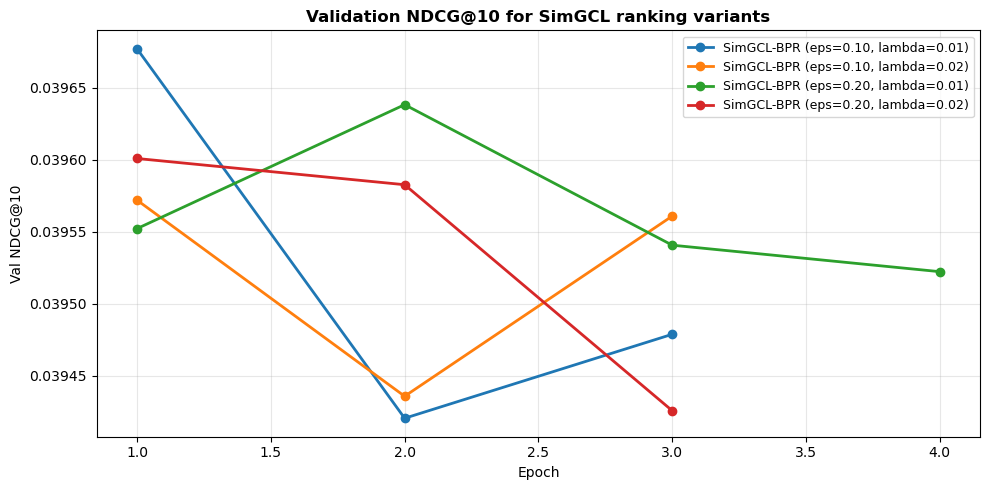

In [60]:
print_section('Training SimGCL-Style LightGCN Ranking Variants')

simgcl_config_specs = [
    {
        'config_name': 'SimGCL-BPR (eps=0.10, lambda=0.01)',
        'eps': 0.10,
        'cl_weight': 0.01,
        'checkpoint_path': model_dir / 'recon_combined_simgcl_rank_eps010_lam001.pth',
    },
    {
        'config_name': 'SimGCL-BPR (eps=0.10, lambda=0.02)',
        'eps': 0.10,
        'cl_weight': 0.02,
        'checkpoint_path': model_dir / 'recon_combined_simgcl_rank_eps010_lam002.pth',
    },
    {
        'config_name': 'SimGCL-BPR (eps=0.20, lambda=0.01)',
        'eps': 0.20,
        'cl_weight': 0.01,
        'checkpoint_path': model_dir / 'recon_combined_simgcl_rank_eps020_lam001.pth',
    },
    {
        'config_name': 'SimGCL-BPR (eps=0.20, lambda=0.02)',
        'eps': 0.20,
        'cl_weight': 0.02,
        'checkpoint_path': model_dir / 'recon_combined_simgcl_rank_eps020_lam002.pth',
    },
]

simgcl_training_results = []
simgcl_histories = {}

for spec in simgcl_config_specs:
    print_subsection(f"Training {spec['config_name']}")
    history_df, best_val_ndcg, best_val_recall = train_simgcl_ranking_config(
        config_name=spec['config_name'],
        adj_mat=norm_adj_tensor,
        checkpoint_path=spec['checkpoint_path'],
        positive_df=simgcl_positive_df,
        user_observed_items=simgcl_user_observed_items,
        cl_weight=spec['cl_weight'],
        eps=spec['eps'],
        temperature=0.2,
        num_epochs=5,
        patience=2,
        lr=3e-4,
        reg_weight=1e-4,
        batch_size=1024,
    )
    simgcl_histories[spec['config_name']] = history_df
    simgcl_training_results.append({
        'Config': spec['config_name'],
        'eps': spec['eps'],
        'cl_weight': spec['cl_weight'],
        'checkpoint_path': spec['checkpoint_path'],
        'best_val_ndcg': best_val_ndcg,
        'best_val_recall': best_val_recall,
    })

simgcl_training_results_df = pd.DataFrame(simgcl_training_results)
display(simgcl_training_results_df)

fig, ax = plt.subplots(figsize=(10, 5))
for config_name, history_df in simgcl_histories.items():
    ax.plot(history_df['epoch'], history_df['val_ndcg'], marker='o', linewidth=2, label=config_name)
ax.set_title('Validation NDCG@10 for SimGCL ranking variants', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val NDCG@10')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


Evaluating the Best SimGCL Ranking Variant


,Method,NDCG@10,Recall@10,Precision@10,MRR,num_users
0,Baseline LightGCN-BPR,0.036324,0.06559,0.006559,0.027489,NaN
1,"SimGCL-BPR (eps=0.10, lambda=0.01)",0.036331,0.06559,0.006559,0.027502,14804.0


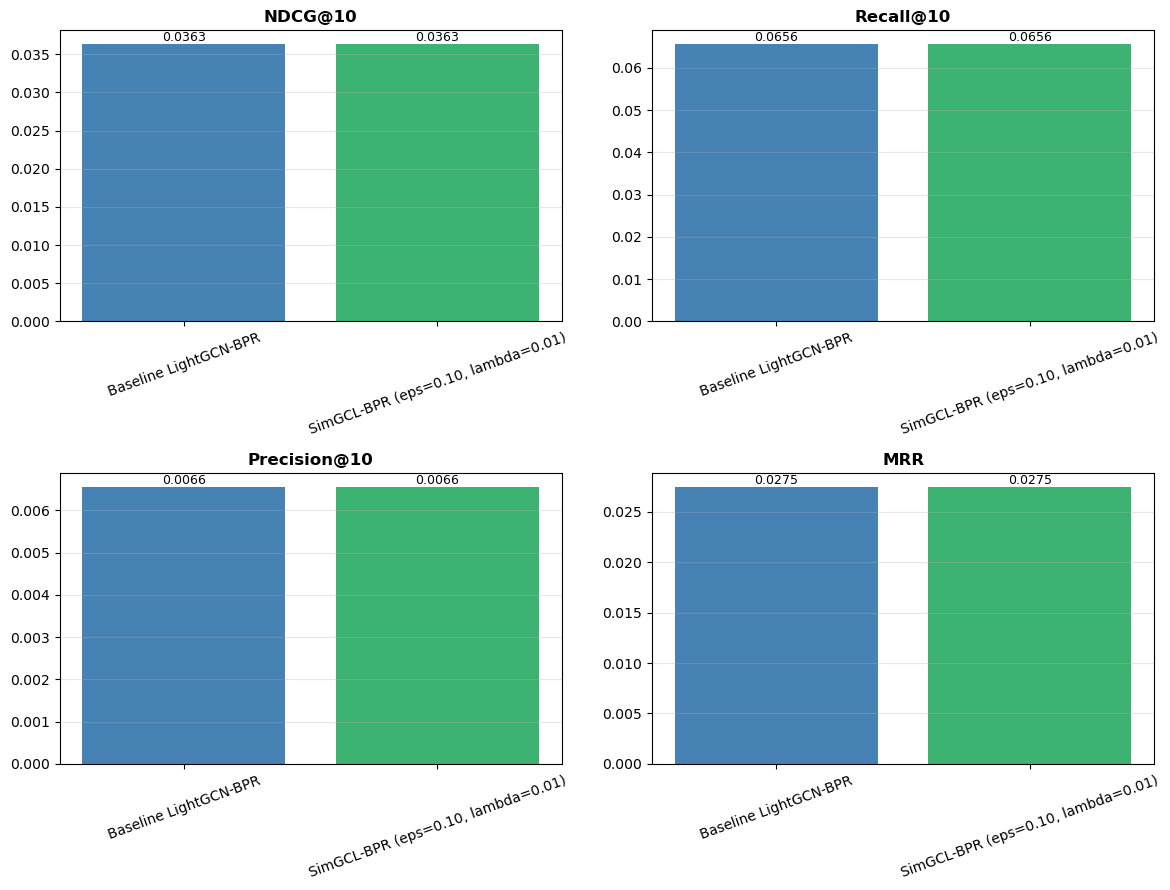


Best SimGCL Ranking Result
Best config: SimGCL-BPR (eps=0.10, lambda=0.01)
Validation NDCG@10: 0.0397
NDCG@10: 0.0363
Recall@10: 0.0656
Precision@10: 0.0066
MRR: 0.0275
num_users: 14804.0000


In [61]:
if 'base_lightgcn_bpr_metrics' not in globals():
    print('base_lightgcn_bpr_metrics not found; rebuilding LightGCN-BPR baseline metrics...')
    _base_lightgcn_bpr_model = LightGCN(n_users, n_items, embedding_dim=64, n_layers=3).to(device)
    _base_lightgcn_bpr_model.load_state_dict(torch.load(MODEL_PATHS['lightgcn_bpr'], map_location=device))
    if 'evaluate_lightgcn_ranking_with_adj' in globals():
        base_lightgcn_bpr_metrics = evaluate_lightgcn_ranking_with_adj(
            _base_lightgcn_bpr_model,
            norm_adj_tensor,
            test_data,
            top_k=10,
        )
    else:
        base_lightgcn_bpr_metrics = compute_ranking_metrics(
            _base_lightgcn_bpr_model,
            test_data,
            model_type='lightgcn',
            top_k=10,
        )

print_section('Evaluating the Best SimGCL Ranking Variant')

best_simgcl_row = simgcl_training_results_df.sort_values(
    ['best_val_ndcg', 'best_val_recall'],
    ascending=[False, False],
).iloc[0]

best_simgcl_model = LightGCN(n_users, n_items, embedding_dim=64, n_layers=3).to(device)
best_simgcl_model.load_state_dict(torch.load(best_simgcl_row['checkpoint_path'], map_location=device))
best_simgcl_metrics = evaluate_lightgcn_ranking_with_adj(
    best_simgcl_model,
    norm_adj_tensor,
    test_data,
    top_k=10,
)

simgcl_comparison_df = pd.DataFrame([
    {
        'Method': 'Baseline LightGCN-BPR',
        'NDCG@10': base_lightgcn_bpr_metrics['NDCG@10'],
        'Recall@10': base_lightgcn_bpr_metrics['Recall@10'],
        'Precision@10': base_lightgcn_bpr_metrics['Precision@10'],
        'MRR': base_lightgcn_bpr_metrics['MRR'],
    },
    {
        'Method': best_simgcl_row['Config'],
        **best_simgcl_metrics,
    },
])

display(simgcl_comparison_df)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
for ax, metric_name in zip(axes, ['NDCG@10', 'Recall@10', 'Precision@10', 'MRR']):
    bars = ax.bar(simgcl_comparison_df['Method'], simgcl_comparison_df[metric_name], color=['steelblue', 'mediumseagreen'])
    ax.set_title(metric_name, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print_section('Best SimGCL Ranking Result')
print(f"Best config: {best_simgcl_row['Config']}")
print(f"Validation NDCG@10: {best_simgcl_row['best_val_ndcg']:.4f}")
for metric_name, metric_value in best_simgcl_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

<a id='section-64-svd-graph-fusion'></a>
##### 6.4 SVD Graph Fusion

- Path: build an SVD-smoothed global collaborative graph and fuse it with the original LightGCN graph
- Source: copied from the RS graph-fusion extension
- Target: test whether global collaborative edges improve LightGCN-BPR ranking

In [62]:
from scipy.sparse.linalg import svds


def build_weighted_interaction_matrix(train_df, n_users, n_items):
    """Build a sparse rating-weighted user-item matrix using only training interactions."""
    user_indices = train_df['user_idx'].to_numpy(dtype=np.int64)
    item_indices = train_df['item_idx'].to_numpy(dtype=np.int64)
    ratings = train_df['rating'].to_numpy(dtype=np.float32)
    values = np.clip((ratings - 1.0) / 4.0, 0.0, 1.0).astype(np.float32)
    return sp.csr_matrix((values, (user_indices, item_indices)), shape=(n_users, n_items))


def compute_svd_factors(interaction_matrix, latent_dim=64):
    """Compute truncated SVD user/item factors."""
    latent_dim = min(latent_dim, max(1, min(interaction_matrix.shape) - 1))
    u, singular_values, vt = svds(interaction_matrix, k=latent_dim)
    sort_idx = np.argsort(singular_values)[::-1]
    singular_values = singular_values[sort_idx]
    u = u[:, sort_idx]
    vt = vt[sort_idx, :]

    singular_sqrt = np.sqrt(np.clip(singular_values, 1e-8, None)).astype(np.float32)
    user_factors = (u * singular_sqrt.reshape(1, -1)).astype(np.float32)
    item_factors = (vt.T * singular_sqrt.reshape(1, -1)).astype(np.float32)
    return user_factors, item_factors, singular_values.astype(np.float32)


def build_svd_global_edges(user_factors, item_factors, observed_items_map, top_k=20, batch_users=512):
    """Build a global collaborative graph from top-K SVD recommendations per user."""
    global_user_indices = []
    global_item_indices = []
    global_weights = []

    item_factor_matrix = item_factors.T.astype(np.float32)
    num_users_local = user_factors.shape[0]

    for start in range(0, num_users_local, batch_users):
        end = min(start + batch_users, num_users_local)
        batch_user_factors = user_factors[start:end]
        batch_scores = np.matmul(batch_user_factors, item_factor_matrix)

        for offset, user_idx in enumerate(range(start, end)):
            scores = batch_scores[offset].copy()
            seen_items = observed_items_map.get(int(user_idx), set())
            if seen_items:
                seen_idx = np.fromiter(seen_items, dtype=np.int64)
                scores[seen_idx] = -1e9

            candidate_k = min(top_k, scores.shape[0])
            if candidate_k <= 0:
                continue

            top_items = np.argpartition(scores, -candidate_k)[-candidate_k:]
            top_scores = scores[top_items]
            order = np.argsort(top_scores)[::-1]
            top_items = top_items[order]
            top_scores = top_scores[order]

            normalized_scores = 1.0 / (1.0 + np.exp(-top_scores))
            for item_idx, weight in zip(top_items, normalized_scores):
                global_user_indices.append(int(user_idx))
                global_item_indices.append(int(item_idx))
                global_weights.append(float(weight))

    return (
        np.asarray(global_user_indices, dtype=np.int64),
        np.asarray(global_item_indices, dtype=np.int64),
        np.asarray(global_weights, dtype=np.float32),
    )


def build_fused_graph_adj(train_df, n_users, n_items, global_user_indices, global_item_indices,
                          global_weights, global_weight_scale=0.2):
    """Fuse the original graph with the SVD global graph."""
    local_user_indices = train_df['user_idx'].to_numpy(dtype=np.int64)
    local_item_indices = train_df['item_idx'].to_numpy(dtype=np.int64)
    local_weights = np.ones(len(train_df), dtype=np.float32)

    fused_user_indices = np.concatenate([local_user_indices, global_user_indices])
    fused_item_indices = np.concatenate([local_item_indices, global_item_indices])
    fused_weights = np.concatenate([local_weights, global_weight_scale * global_weights]).astype(np.float32)

    row = np.concatenate([fused_user_indices, fused_item_indices + n_users])
    col = np.concatenate([fused_item_indices + n_users, fused_user_indices])
    data = np.concatenate([fused_weights, fused_weights]).astype(np.float32)

    adj_mat = sp.coo_matrix((data, (row, col)), shape=(n_users + n_items, n_users + n_items))
    rowsum = np.array(adj_mat.sum(1)).flatten()
    d_inv = np.zeros_like(rowsum, dtype=np.float32)
    np.power(rowsum, -0.5, out=d_inv, where=rowsum > 0)
    d_mat_inv = sp.diags(d_inv)
    norm_adj = d_mat_inv.dot(adj_mat).dot(d_mat_inv).tocoo()

    indices = torch.LongTensor(np.vstack((norm_adj.row, norm_adj.col)))
    values = torch.FloatTensor(norm_adj.data)
    shape = torch.Size(norm_adj.shape)
    return torch.sparse.FloatTensor(indices, values, shape).coalesce().to(device)


interaction_matrix_fusion = build_weighted_interaction_matrix(train_data, n_users, n_items)
svd_user_factors_fusion, svd_item_factors_fusion, svd_singular_values_fusion = compute_svd_factors(
    interaction_matrix_fusion,
    latent_dim=64,
)
global_graph_user_indices, global_graph_item_indices, global_graph_weights = build_svd_global_edges(
    svd_user_factors_fusion,
    svd_item_factors_fusion,
    user_positive_items,
    top_k=20,
    batch_users=512,
)

print_section('SVD Graph Fusion Setup')
print(f"Interaction matrix shape: {interaction_matrix_fusion.shape}")
print(f"Training interactions: {interaction_matrix_fusion.nnz}")
print(f"Latent dimension: {svd_user_factors_fusion.shape[1]}")
print(f"Top singular value: {svd_singular_values_fusion[0]:.4f}")
print(f"Global collaborative edges: {len(global_graph_weights)}")


SVD Graph Fusion Setup
Interaction matrix shape: (17500, 9237)
Training interactions: 47855
Latent dimension: 64
Top singular value: 18.9785
Global collaborative edges: 350000



Training SVD Graph Fusion Variants

Training Graph fusion (topk=10, global_weight=0.10)
---------------------------------------------------
Graph fusion (topk=10, global_weight=0.10) | Epoch 01/5 | Loss: 0.0650 | Val NDCG@10: 0.0399
Graph fusion (topk=10, global_weight=0.10) | Epoch 02/5 | Loss: 0.0624 | Val NDCG@10: 0.0398
Graph fusion (topk=10, global_weight=0.10) | Epoch 03/5 | Loss: 0.0625 | Val NDCG@10: 0.0399
Graph fusion (topk=10, global_weight=0.10) | Epoch 04/5 | Loss: 0.0608 | Val NDCG@10: 0.0399
Graph fusion (topk=10, global_weight=0.10) | Epoch 05/5 | Loss: 0.0592 | Val NDCG@10: 0.0400

Training Graph fusion (topk=10, global_weight=0.20)
---------------------------------------------------
Graph fusion (topk=10, global_weight=0.20) | Epoch 01/5 | Loss: 0.0865 | Val NDCG@10: 0.0390
Graph fusion (topk=10, global_weight=0.20) | Epoch 02/5 | Loss: 0.0845 | Val NDCG@10: 0.0390
Graph fusion (topk=10, global_weight=0.20) | Epoch 03/5 | Loss: 0.0816 | Val NDCG@10: 0.0390
Graph fusi

,Config,top_k_global,global_weight_scale,checkpoint_path,best_val_ndcg,best_val_recall
0,"Graph fusion (topk=10, global_weight=0.10)",10,0.1,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...,0.039965,0.074417
1,"Graph fusion (topk=10, global_weight=0.20)",10,0.2,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...,0.039332,0.072604
2,"Graph fusion (topk=20, global_weight=0.10)",20,0.1,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...,0.039874,0.074283
3,"Graph fusion (topk=20, global_weight=0.20)",20,0.2,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...,0.037636,0.068171


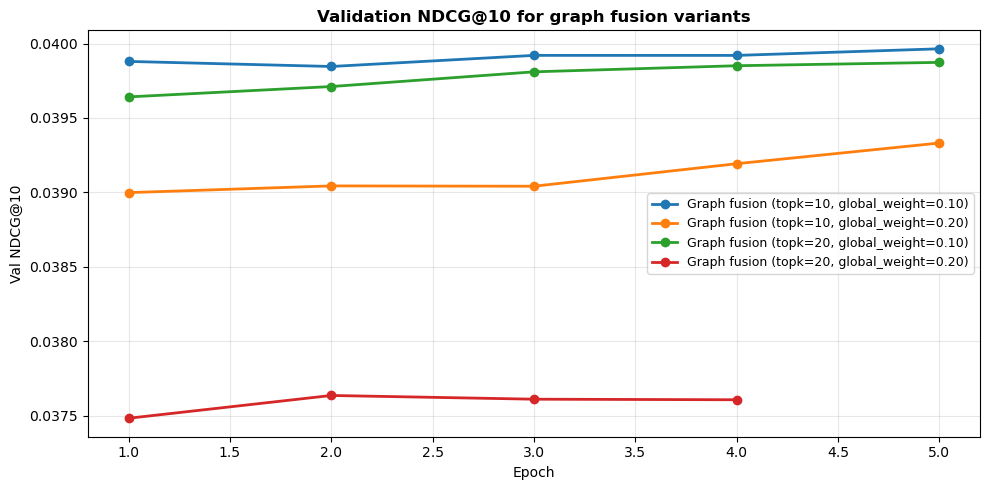

In [63]:
print_section('Training SVD Graph Fusion Variants')

graph_fusion_config_specs = [
    {
        'config_name': 'Graph fusion (topk=10, global_weight=0.10)',
        'top_k_global': 10,
        'global_weight_scale': 0.10,
        'checkpoint_path': model_dir / 'recon_combined_graph_fusion_top10_w010.pth',
    },
    {
        'config_name': 'Graph fusion (topk=10, global_weight=0.20)',
        'top_k_global': 10,
        'global_weight_scale': 0.20,
        'checkpoint_path': model_dir / 'recon_combined_graph_fusion_top10_w020.pth',
    },
    {
        'config_name': 'Graph fusion (topk=20, global_weight=0.10)',
        'top_k_global': 20,
        'global_weight_scale': 0.10,
        'checkpoint_path': model_dir / 'recon_combined_graph_fusion_top20_w010.pth',
    },
    {
        'config_name': 'Graph fusion (topk=20, global_weight=0.20)',
        'top_k_global': 20,
        'global_weight_scale': 0.20,
        'checkpoint_path': model_dir / 'recon_combined_graph_fusion_top20_w020.pth',
    },
]

graph_fusion_results = []
graph_fusion_histories = {}
graph_fusion_adj_mats = {}

for spec in graph_fusion_config_specs:
    print_subsection(f"Training {spec['config_name']}")
    global_user_indices_cfg, global_item_indices_cfg, global_weights_cfg = build_svd_global_edges(
        svd_user_factors_fusion,
        svd_item_factors_fusion,
        user_positive_items,
        top_k=spec['top_k_global'],
        batch_users=512,
    )
    fused_adj_mat = build_fused_graph_adj(
        train_data,
        n_users,
        n_items,
        global_user_indices_cfg,
        global_item_indices_cfg,
        global_weights_cfg,
        global_weight_scale=spec['global_weight_scale'],
    )
    graph_fusion_adj_mats[spec['config_name']] = fused_adj_mat

    model = LightGCN(n_users, n_items, embedding_dim=64, n_layers=3).to(device)
    model.load_state_dict(torch.load(MODEL_PATHS['lightgcn_bpr'], map_location=device))
    optimizer_fusion = torch.optim.Adam(model.parameters(), lr=3e-4)

    best_val_ndcg = -1.0
    best_val_recall = -1.0
    patience_counter = 0
    history_rows = []

    for epoch in range(5):
        train_loss = train_lightgcn_bpr_epoch(
            model,
            fused_adj_mat,
            train_data,
            user_positive_items,
            n_items,
            optimizer_fusion,
            reg_weight=1e-4,
            batch_size=1024,
            device=device,
        )
        val_metrics = evaluate_lightgcn_ranking_with_adj(model, fused_adj_mat, val_data, top_k=10)
        history_rows.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_ndcg': val_metrics['NDCG@10'],
            'val_recall': val_metrics['Recall@10'],
        })

        print(
            f"{spec['config_name']} | Epoch {epoch + 1:02d}/5 | Loss: {train_loss:.4f} | "
            f"Val NDCG@10: {val_metrics['NDCG@10']:.4f}"
        )

        improved = (
            val_metrics['NDCG@10'] > best_val_ndcg
            or (val_metrics['NDCG@10'] == best_val_ndcg and val_metrics['Recall@10'] > best_val_recall)
        )
        if improved:
            best_val_ndcg = val_metrics['NDCG@10']
            best_val_recall = val_metrics['Recall@10']
            patience_counter = 0
            torch.save(model.state_dict(), spec['checkpoint_path'])
        else:
            patience_counter += 1
            if patience_counter >= 2:
                print(f"Early stopping {spec['config_name']} at epoch {epoch + 1}")
                break

    history_df = pd.DataFrame(history_rows)
    graph_fusion_histories[spec['config_name']] = history_df
    graph_fusion_results.append({
        'Config': spec['config_name'],
        'top_k_global': spec['top_k_global'],
        'global_weight_scale': spec['global_weight_scale'],
        'checkpoint_path': spec['checkpoint_path'],
        'best_val_ndcg': best_val_ndcg,
        'best_val_recall': best_val_recall,
    })

graph_fusion_results_df = pd.DataFrame(graph_fusion_results)
display(graph_fusion_results_df)

fig, ax = plt.subplots(figsize=(10, 5))
for config_name, history_df in graph_fusion_histories.items():
    ax.plot(history_df['epoch'], history_df['val_ndcg'], marker='o', linewidth=2, label=config_name)
ax.set_title('Validation NDCG@10 for graph fusion variants', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val NDCG@10')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


Evaluating the Best Graph Fusion Model


,Method,NDCG@10,Recall@10,Precision@10,MRR,num_users
0,Baseline LightGCN-BPR,0.036324,0.065590,0.006559,0.027489,NaN
1,"Graph fusion (topk=10, global_weight=0.10)",0.037486,0.067617,0.006762,0.028375,14804.0


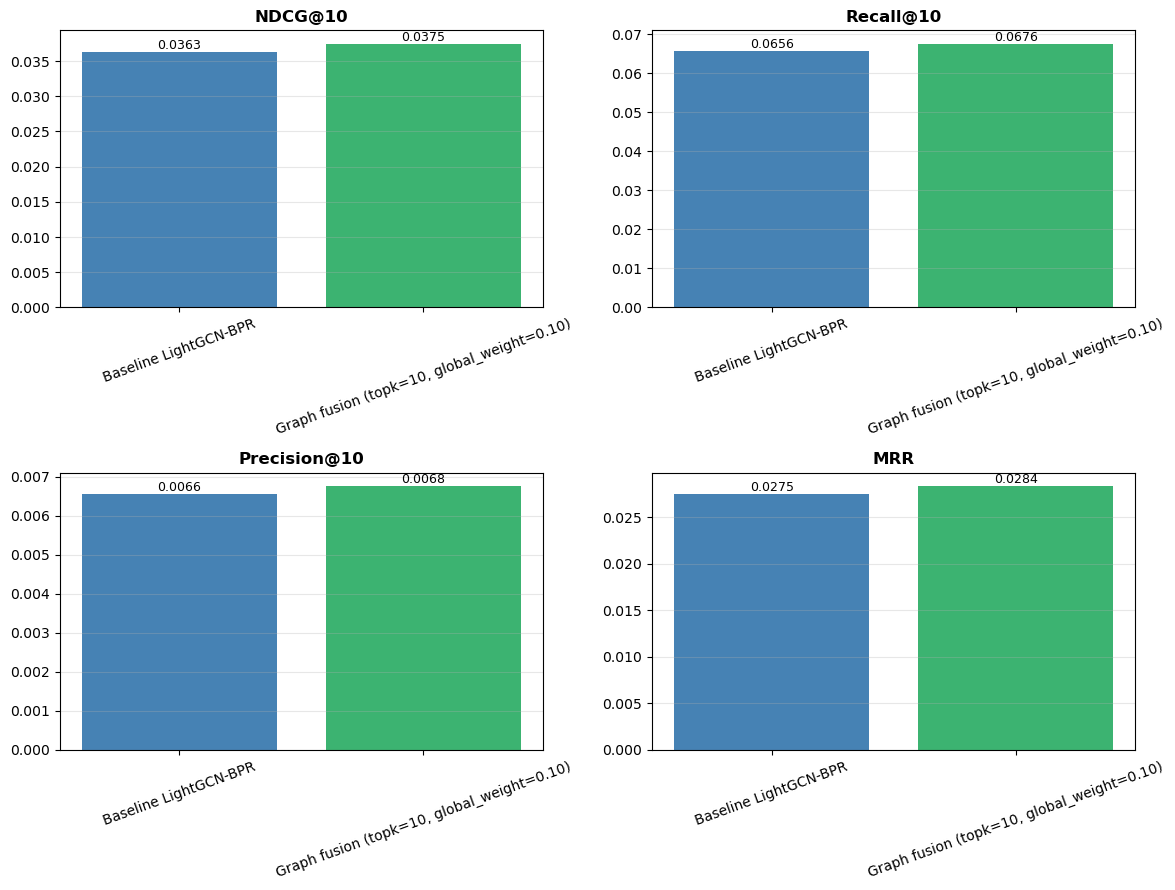


Best Graph Fusion Result
Best config: Graph fusion (topk=10, global_weight=0.10)
Validation NDCG@10: 0.0400
NDCG@10: 0.0375
Recall@10: 0.0676
Precision@10: 0.0068
MRR: 0.0284
num_users: 14804.0000


In [64]:
if 'base_lightgcn_bpr_metrics' not in globals():
    print('base_lightgcn_bpr_metrics not found; rebuilding LightGCN-BPR baseline metrics...')
    _base_lightgcn_bpr_model = LightGCN(n_users, n_items, embedding_dim=64, n_layers=3).to(device)
    _base_lightgcn_bpr_model.load_state_dict(torch.load(MODEL_PATHS['lightgcn_bpr'], map_location=device))
    if 'evaluate_lightgcn_ranking_with_adj' in globals():
        base_lightgcn_bpr_metrics = evaluate_lightgcn_ranking_with_adj(
            _base_lightgcn_bpr_model,
            norm_adj_tensor,
            test_data,
            top_k=10,
        )
    else:
        base_lightgcn_bpr_metrics = compute_ranking_metrics(
            _base_lightgcn_bpr_model,
            test_data,
            model_type='lightgcn',
            top_k=10,
        )

print_section('Evaluating the Best Graph Fusion Model')

best_graph_fusion_row = graph_fusion_results_df.sort_values(
    ['best_val_ndcg', 'best_val_recall'],
    ascending=[False, False],
).iloc[0]

best_graph_fusion_model = LightGCN(n_users, n_items, embedding_dim=64, n_layers=3).to(device)
best_graph_fusion_model.load_state_dict(torch.load(best_graph_fusion_row['checkpoint_path'], map_location=device))
best_graph_fusion_adj = graph_fusion_adj_mats[best_graph_fusion_row['Config']]
best_graph_fusion_metrics = evaluate_lightgcn_ranking_with_adj(
    best_graph_fusion_model,
    best_graph_fusion_adj,
    test_data,
    top_k=10,
)

graph_fusion_comparison_df = pd.DataFrame([
    {
        'Method': 'Baseline LightGCN-BPR',
        'NDCG@10': base_lightgcn_bpr_metrics['NDCG@10'],
        'Recall@10': base_lightgcn_bpr_metrics['Recall@10'],
        'Precision@10': base_lightgcn_bpr_metrics['Precision@10'],
        'MRR': base_lightgcn_bpr_metrics['MRR'],
    },
    {
        'Method': best_graph_fusion_row['Config'],
        **best_graph_fusion_metrics,
    },
])

display(graph_fusion_comparison_df)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
for ax, metric_name in zip(axes, ['NDCG@10', 'Recall@10', 'Precision@10', 'MRR']):
    bars = ax.bar(graph_fusion_comparison_df['Method'], graph_fusion_comparison_df[metric_name], color=['steelblue', 'mediumseagreen'])
    ax.set_title(metric_name, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print_section('Best Graph Fusion Result')
print(f"Best config: {best_graph_fusion_row['Config']}")
print(f"Validation NDCG@10: {best_graph_fusion_row['best_val_ndcg']:.4f}")
for metric_name, metric_value in best_graph_fusion_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

<a id='section-65-gatv2-bpr'></a>
##### 6.5 GATv2-BPR

- Path: original GAT recommendation pipeline from the teammate experiment
- Source: model architecture and loss are kept unchanged; checkpoint selection uses validation NDCG
- Target: reuse the original GAT method on Musical Instruments under the shared data split


GAT params: 1,778,368
E  1 * loss=0.6386 bpr=0.6385 R@20=0.0437 N@20=0.0168 4.5s
E  2 * loss=0.4320 bpr=0.4319 R@20=0.0529 N@20=0.0197 4.5s
E  3   loss=0.3951 bpr=0.3950 R@20=0.0485 N@20=0.0186 4.0s
E  4 * loss=0.3835 bpr=0.3834 R@20=0.0513 N@20=0.0221 4.0s
E  5 * loss=0.3811 bpr=0.3810 R@20=0.0547 N@20=0.0226 4.1s
E  6 * loss=0.3708 bpr=0.3707 R@20=0.0533 N@20=0.0230 4.2s
E  7   loss=0.3526 bpr=0.3525 R@20=0.0469 N@20=0.0216 4.1s
E  8   loss=0.3317 bpr=0.3316 R@20=0.0513 N@20=0.0207 4.1s
E  9   loss=0.3057 bpr=0.3056 R@20=0.0440 N@20=0.0184 4.3s
E 10   loss=0.2938 bpr=0.2937 R@20=0.0458 N@20=0.0184 4.3s
E 11   loss=0.2813 bpr=0.2812 R@20=0.0434 N@20=0.0178 4.6s
early stop

TEST  R@20=0.0520  N@20=0.0227


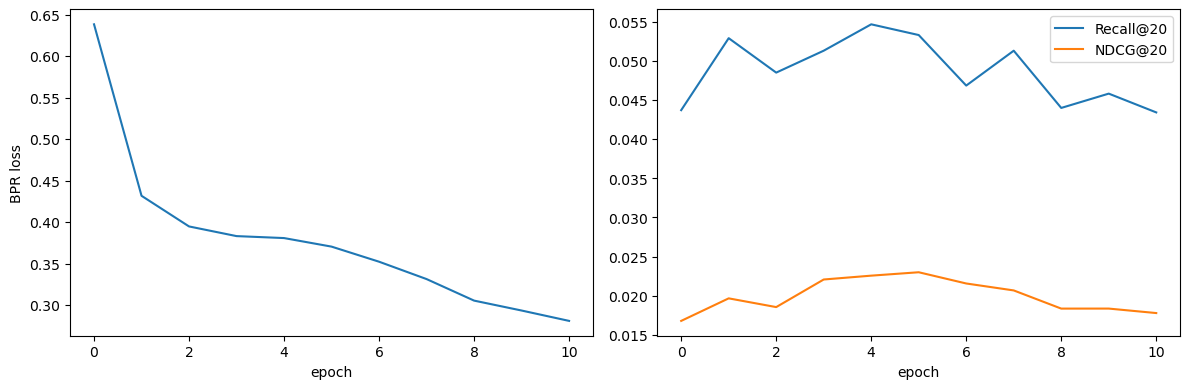

In [65]:
if not HAS_TORCH_GEOMETRIC:
    print('Skipping GATv2-BPR section because torch_geometric is not installed.')
    print('Install it in the notebook environment, then rerun this section.')
    print(GATV2_IMPORT_ERROR)
    gat_history = None
    gat_metrics = None
else:
    def build_edge_index_from_train_df(train_df: pd.DataFrame, n_users: int, n_items: int) -> torch.Tensor:
        user_indices = train_df['user_idx'].to_numpy(dtype=np.int64)
        item_indices = train_df['item_idx'].to_numpy(dtype=np.int64)
        row = np.concatenate([user_indices, item_indices + n_users])
        col = np.concatenate([item_indices + n_users, user_indices])
        edge_index = torch.LongTensor(np.vstack([row, col])).to(device)
        return edge_index


    class GATOriginalBPRDataset(Dataset):
        def __init__(self, train_df, n_items):
            self.users = train_df['user_idx'].values.astype(np.int64)
            self.pos_items = train_df['item_idx'].values.astype(np.int64)
            self.n_items = n_items
            self.user_pos = defaultdict(set)
            for u, i in zip(self.users, self.pos_items):
                self.user_pos[u].add(i)

        def __len__(self):
            return len(self.users)

        def __getitem__(self, idx):
            u = int(self.users[idx])
            pos = int(self.pos_items[idx])
            while True:
                neg = np.random.randint(self.n_items)
                if neg not in self.user_pos[u]:
                    break
            return u, pos, neg


    class GATCF(nn.Module):
        def __init__(self, n_users, n_items, embedding_dim=64, n_layers=2, n_heads=4, dropout=0.0):
            super().__init__()
            self.n_users = n_users
            self.n_items = n_items

            self.user_emb = nn.Embedding(n_users, embedding_dim)
            self.item_emb = nn.Embedding(n_items, embedding_dim)
            nn.init.normal_(self.user_emb.weight, std=0.1)
            nn.init.normal_(self.item_emb.weight, std=0.1)

            self.gat_layers = nn.ModuleList([
                GATv2Conv(embedding_dim, embedding_dim, heads=n_heads, concat=False, dropout=dropout, add_self_loops=True)
                for _ in range(n_layers)
            ])

        def propagate(self, edge_index):
            x = torch.cat([self.user_emb.weight, self.item_emb.weight], dim=0)
            for i, layer in enumerate(self.gat_layers):
                x = layer(x, edge_index)
                if i < len(self.gat_layers) - 1:
                    x = F.elu(x)
            return torch.split(x, [self.n_users, self.n_items], dim=0)

        def bpr_loss(self, users, pos, neg, edge_index, l2_reg=1e-4):
            users_out, items_out = self.propagate(edge_index)
            u_e, p_e, n_e = users_out[users], items_out[pos], items_out[neg]
            bpr = -F.logsigmoid((u_e * p_e).sum(-1) - (u_e * n_e).sum(-1)).mean()

            u0 = self.user_emb(users)
            p0 = self.item_emb(pos)
            n0 = self.item_emb(neg)
            reg = (u0.pow(2).sum() + p0.pow(2).sum() + n0.pow(2).sum()) / users.size(0)

            return bpr + l2_reg * 0.5 * reg, bpr.item()


    @torch.no_grad()
    def evaluate_gat_original(model, train_df, eval_df, edge_index, K=20, batch_size=512):
        model.eval()
        users_out, items_out = model.propagate(edge_index)

        train_mask = defaultdict(list)
        for u, i in zip(train_df['user_idx'].values, train_df['item_idx'].values):
            train_mask[int(u)].append(int(i))

        eval_users = eval_df['user_idx'].values.astype(np.int64)
        eval_items = eval_df['item_idx'].values.astype(np.int64)

        recalls, ndcgs = [], []
        for start in range(0, len(eval_users), batch_size):
            u_batch = eval_users[start:start + batch_size]
            target_batch = eval_items[start:start + batch_size]

            u_emb = users_out[torch.from_numpy(u_batch).to(device)]
            scores = u_emb @ items_out.T

            for bi, u in enumerate(u_batch):
                if u in train_mask:
                    scores[bi, train_mask[u]] = float('-inf')

            _, topk = scores.topk(K, dim=-1)
            topk = topk.cpu().numpy()

            for bi, target in enumerate(target_batch):
                hits = (topk[bi] == target)
                if hits.any():
                    rank = int(hits.argmax())
                    recalls.append(1.0)
                    ndcgs.append(1.0 / np.log2(rank + 2))
                else:
                    recalls.append(0.0)
                    ndcgs.append(0.0)

        return float(np.mean(recalls)), float(np.mean(ndcgs))


    def train_gat(model, edge_index, loader, train_df, val_df, n_epochs=50, lr=1e-3, l2_reg=1e-4, K=20, patience=5, ckpt_path='gat_best.pt'):
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        history = {'loss': [], 'bpr': [], 'val_recall': [], 'val_ndcg': []}
        best, no_improve = -1.0, 0

        for epoch in range(n_epochs):
            model.train()
            t0 = time.time()
            total_loss, total_bpr, n = 0.0, 0.0, 0

            for users, pos, neg in loader:
                users, pos, neg = users.to(device), pos.to(device), neg.to(device)
                opt.zero_grad()
                loss, bpr = model.bpr_loss(users, pos, neg, edge_index, l2_reg=l2_reg)
                loss.backward()
                opt.step()
                total_loss += loss.item()
                total_bpr += bpr
                n += 1

            avg_loss, avg_bpr = total_loss / n, total_bpr / n
            recall, ndcg = evaluate_gat_original(model, train_df, val_df, edge_index, K=K)
            elapsed = time.time() - t0

            history['loss'].append(avg_loss)
            history['bpr'].append(avg_bpr)
            history['val_recall'].append(recall)
            history['val_ndcg'].append(ndcg)

            improved = ndcg > best
            print(f"E{epoch + 1:3d} {'*' if improved else ' '} loss={avg_loss:.4f} bpr={avg_bpr:.4f} R@{K}={recall:.4f} N@{K}={ndcg:.4f} {elapsed:.1f}s")

            if improved:
                best, no_improve = ndcg, 0
                torch.save(model.state_dict(), ckpt_path)
            else:
                no_improve += 1
                if no_improve >= patience:
                    print('early stop')
                    break
        return history


    def evaluate_gat_unified_metrics(model, eval_df, edge_index, top_k=None):
        if top_k is None:
            top_k = EXPERIMENT_CONFIG['ranking_top_k']
        model.eval()
        user_items = defaultdict(list)
        for _, row in eval_df.iterrows():
            user_items[int(row['user_idx'])].append({'item': int(row['item_idx']), 'rating': float(row['rating'])})

        ndcg_scores, recall_scores, precision_scores, mrr_scores = [], [], [], []
        with torch.no_grad():
            users_out, items_out = model.propagate(edge_index)
            for user_idx, items_data in user_items.items():
                relevant_items = {d['item'] for d in items_data if d['rating'] >= EXPERIMENT_CONFIG['relevance_threshold']}
                if not relevant_items:
                    continue
                scores = users_out[user_idx] @ items_out.T
                seen_items = list(user_positive_items.get(user_idx, set()))
                if seen_items:
                    scores = scores.clone()
                    scores[seen_items] = -1e9
                _, top_items = torch.topk(scores, top_k)
                top_items = top_items.cpu().numpy()
                hits = [1 if item in relevant_items else 0 for item in top_items]
                dcg = sum(hits[i] / np.log2(i + 2) for i in range(len(hits)))
                idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant_items), top_k)))
                ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
                recall_scores.append(sum(hits) / len(relevant_items))
                precision_scores.append(sum(hits) / top_k)
                reciprocal_rank = 0.0
                for rank, item in enumerate(top_items, start=1):
                    if item in relevant_items:
                        reciprocal_rank = 1.0 / rank
                        break
                mrr_scores.append(reciprocal_rank)

        return {
            'NDCG@10': float(np.mean(ndcg_scores)) if ndcg_scores else 0.0,
            'Recall@10': float(np.mean(recall_scores)) if recall_scores else 0.0,
            'Precision@10': float(np.mean(precision_scores)) if precision_scores else 0.0,
            'MRR': float(np.mean(mrr_scores)) if mrr_scores else 0.0,
            'num_users': len(ndcg_scores),
        }


    edge_index = build_edge_index_from_train_df(train_data, n_users, n_items)
    gat_train_dataset = GATOriginalBPRDataset(train_data, n_items)
    gat_train_loader = DataLoader(gat_train_dataset, batch_size=1024, shuffle=True, num_workers=0)
    gat_ckpt_path = model_dir / 'best_gat_original_bpr_ndcg_model.pth'

    gat_model = GATCF(n_users, n_items, embedding_dim=64, n_layers=2, n_heads=4).to(device)
    print(f"GAT params: {sum(p.numel() for p in gat_model.parameters() if p.requires_grad):,}")

    if gat_ckpt_path.exists() and not EXPERIMENT_CONFIG['force_retrain']:
        gat_model.load_state_dict(torch.load(gat_ckpt_path, map_location=device))
        gat_history = None
        print('Loaded existing GAT checkpoint.')
    else:
        gat_history = train_gat(
            gat_model,
            edge_index,
            gat_train_loader,
            train_data,
            val_data,
            n_epochs=50,
            lr=1e-3,
            l2_reg=1e-4,
            K=20,
            patience=5,
            ckpt_path=str(gat_ckpt_path),
        )
        gat_model.load_state_dict(torch.load(gat_ckpt_path, map_location=device))

    gat_test_recall_at_20, gat_test_ndcg_at_20 = evaluate_gat_original(gat_model, train_data, test_data, edge_index, K=20)
    print(f"\nTEST  R@20={gat_test_recall_at_20:.4f}  N@20={gat_test_ndcg_at_20:.4f}")

    if gat_history is not None:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(gat_history['bpr'])
        axes[0].set_xlabel('epoch')
        axes[0].set_ylabel('BPR loss')
        axes[1].plot(gat_history['val_recall'], label='Recall@20')
        axes[1].plot(gat_history['val_ndcg'], label='NDCG@20')
        axes[1].set_xlabel('epoch')
        axes[1].legend()
        plt.tight_layout()

    gat_metrics = evaluate_gat_unified_metrics(gat_model, test_data, edge_index, top_k=EXPERIMENT_CONFIG['ranking_top_k'])
    gat_metrics


<a id='section-66-lightgcl-bpr'></a>
##### 6.6 LightGCL-BPR

- Path: original LightGCL pipeline from the teammate experiment
- Source: model architecture and loss are kept unchanged; checkpoint selection uses validation NDCG
- Target: reuse the original LightGCL method on Musical Instruments under the shared data split



LightGCL params: 1,711,168
E  1 * loss=2.2660  bpr=0.6925  cl=7.8674  R@20=0.0639  N@20=0.0282  3.5s
E  2   loss=2.2323  bpr=0.6920  cl=7.7016  R@20=0.0635  N@20=0.0281  3.3s
E  3   loss=2.2297  bpr=0.6916  cl=7.6905  R@20=0.0641  N@20=0.0282  3.5s
E  4 * loss=2.2276  bpr=0.6911  cl=7.6824  R@20=0.0646  N@20=0.0283  3.4s
E  5 * loss=2.2262  bpr=0.6903  cl=7.6798  R@20=0.0651  N@20=0.0284  3.6s
E  6 * loss=2.2247  bpr=0.6889  cl=7.6791  R@20=0.0657  N@20=0.0286  3.6s
E  7 * loss=2.2224  bpr=0.6867  cl=7.6786  R@20=0.0657  N@20=0.0286  3.3s
E  8 * loss=2.2193  bpr=0.6832  cl=7.6806  R@20=0.0658  N@20=0.0286  3.1s
E  9   loss=2.2132  bpr=0.6776  cl=7.6782  R@20=0.0658  N@20=0.0286  3.1s
E 10   loss=2.2053  bpr=0.6694  cl=7.6794  R@20=0.0658  N@20=0.0286  3.1s
E 11   loss=2.1936  bpr=0.6579  cl=7.6787  R@20=0.0657  N@20=0.0285  3.3s
E 12   loss=2.1786  bpr=0.6434  cl=7.6760  R@20=0.0651  N@20=0.0283  3.7s
E 13   loss=2.1621  bpr=0.6259  cl=7.6811  R@20=0.0654  N@20=0.0285  3.3s
early stop

{'NDCG@10': 0.02371390001025657,
 'Recall@10': 0.042623615239124564,
 'Precision@10': 0.004262361523912457,
 'MRR': 0.0180029099814293,
 'num_users': 14804}

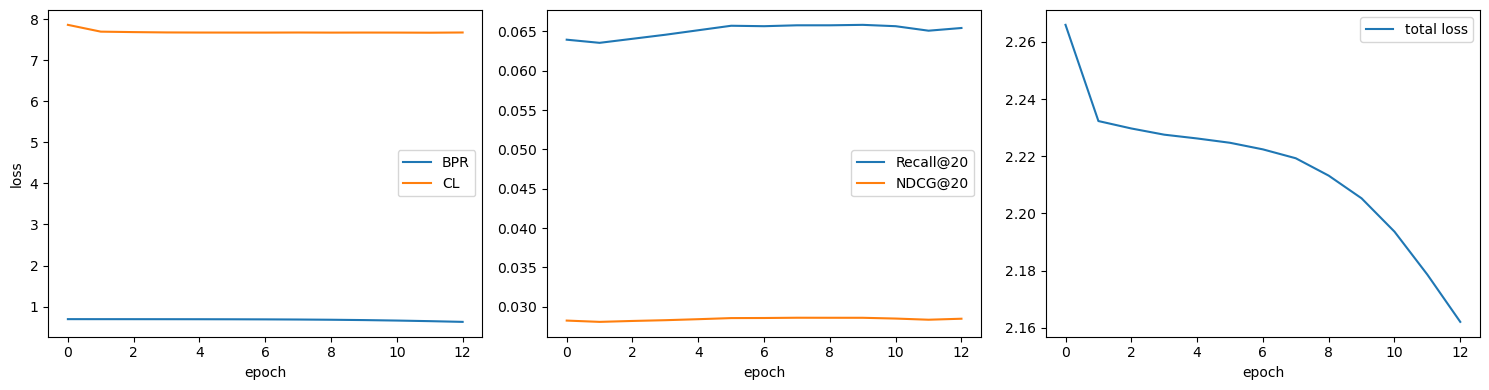

In [66]:
def build_normalized_R(train_df: pd.DataFrame, n_users: int, n_items: int) -> sp.csr_matrix:
    rows = train_df['user_idx'].to_numpy(dtype=np.int64)
    cols = train_df['item_idx'].to_numpy(dtype=np.int64)
    vals = np.ones(len(train_df), dtype=np.float32)
    R = sp.coo_matrix((vals, (rows, cols)), shape=(n_users, n_items)).tocsr()
    user_degree = np.asarray(R.sum(axis=1)).reshape(-1)
    item_degree = np.asarray(R.sum(axis=0)).reshape(-1)
    d_u = np.zeros_like(user_degree, dtype=np.float32)
    d_i = np.zeros_like(item_degree, dtype=np.float32)
    np.power(user_degree, -0.5, out=d_u, where=user_degree > 0)
    np.power(item_degree, -0.5, out=d_i, where=item_degree > 0)
    D_u = sp.diags(d_u)
    D_i = sp.diags(d_i)
    return D_u @ R @ D_i


class LightGCLBPRDataset(Dataset):
    def __init__(self, train_df, n_items):
        self.users = train_df['user_idx'].values.astype(np.int64)
        self.pos = train_df['item_idx'].values.astype(np.int64)
        self.n_items = n_items
        self.user_pos = defaultdict(set)
        for u, i in zip(self.users, self.pos):
            self.user_pos[u].add(i)

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        u = int(self.users[idx])
        p = int(self.pos[idx])
        while True:
            n = np.random.randint(self.n_items)
            if n not in self.user_pos[u]:
                return u, p, n


class LightGCL(nn.Module):
    def __init__(self, n_users, n_items, U_hat, V_hat, d=64, n_layers=2, dropout=0.0):
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.n_layers = n_layers
        self.dropout = dropout

        self.E_u_0 = nn.Parameter(torch.empty(n_users, d))
        self.E_i_0 = nn.Parameter(torch.empty(n_items, d))
        nn.init.xavier_uniform_(self.E_u_0)
        nn.init.xavier_uniform_(self.E_i_0)

        self.register_buffer('U_hat', U_hat)
        self.register_buffer('V_hat', V_hat)

    def edge_drop(self, A_hat):
        if self.dropout <= 0 or not self.training:
            return A_hat
        idx = A_hat._indices()
        val = A_hat._values()
        keep = torch.rand_like(val) > self.dropout
        idx = idx[:, keep]
        val = val[keep] / (1 - self.dropout)
        return torch.sparse_coo_tensor(idx, val, A_hat.shape).coalesce()

    def propagate(self, A_hat):
        A = self.edge_drop(A_hat)

        E_u_list = [self.E_u_0]
        E_i_list = [self.E_i_0]
        G_u_list = [self.E_u_0]
        G_i_list = [self.E_i_0]

        for _ in range(self.n_layers):
            E_prev = torch.cat([E_u_list[-1], E_i_list[-1]], dim=0)
            E_next = torch.sparse.mm(A, E_prev)
            E_u_l, E_i_l = torch.split(E_next, [self.n_users, self.n_items], dim=0)
            E_u_list.append(E_u_l)
            E_i_list.append(E_i_l)

            G_u = self.U_hat @ (self.V_hat.t() @ E_i_list[-2])
            G_i = self.V_hat @ (self.U_hat.t() @ E_u_list[-2])
            G_u_list.append(G_u)
            G_i_list.append(G_i)

        E_u = torch.stack(E_u_list, dim=1).mean(dim=1)
        E_i = torch.stack(E_i_list, dim=1).mean(dim=1)
        return E_u, E_i, G_u_list, G_i_list, E_u_list, E_i_list

    def score(self, users, items, E_u, E_i):
        return (E_u[users] * E_i[items]).sum(dim=-1)


def info_nce(z1, z2, all_z2, tau):
    z1 = F.normalize(z1, dim=-1)
    z2 = F.normalize(z2, dim=-1)
    all_z2 = F.normalize(all_z2, dim=-1)
    pos = (z1 * z2).sum(-1) / tau
    logits = z1 @ all_z2.t() / tau
    return -(pos - torch.logsumexp(logits, dim=-1)).mean()


def lightgcl_loss(model, A_hat, users, pos, neg, tau=0.5, lam_cl=0.2, lam_reg=1e-7):
    E_u, E_i, G_u_list, G_i_list, E_u_list, E_i_list = model.propagate(A_hat)

    s_pos = model.score(users, pos, E_u, E_i)
    s_neg = model.score(users, neg, E_u, E_i)
    bpr = -F.logsigmoid(s_pos - s_neg).mean()

    u_uniq = torch.unique(users)
    i_uniq = torch.unique(torch.cat([pos, neg]))

    cl = 0.0
    for l in range(1, model.n_layers + 1):
        cl = cl + info_nce(E_u_list[l][u_uniq], G_u_list[l][u_uniq], E_u_list[l][u_uniq], tau)
        cl = cl + info_nce(G_u_list[l][u_uniq], E_u_list[l][u_uniq], G_u_list[l][u_uniq], tau)
        cl = cl + info_nce(E_i_list[l][i_uniq], G_i_list[l][i_uniq], E_i_list[l][i_uniq], tau)
        cl = cl + info_nce(G_i_list[l][i_uniq], E_i_list[l][i_uniq], G_i_list[l][i_uniq], tau)
    cl = cl / (4 * model.n_layers)

    reg = (
        model.E_u_0[users].pow(2).sum()
        + model.E_i_0[pos].pow(2).sum()
        + model.E_i_0[neg].pow(2).sum()
    ) / users.size(0)

    loss = bpr + lam_cl * cl + lam_reg * reg
    return loss, bpr.item(), cl.item() if torch.is_tensor(cl) else float(cl)


@torch.no_grad()
def evaluate_lightgcl_original(model, A_hat, train_df, eval_df, K=20, batch_size=512):
    model.eval()
    E_u, E_i, *_ = model.propagate(A_hat)

    train_mask = defaultdict(list)
    for u, i in zip(train_df['user_idx'].values, train_df['item_idx'].values):
        train_mask[int(u)].append(int(i))

    eval_users = eval_df['user_idx'].values.astype(np.int64)
    eval_items = eval_df['item_idx'].values.astype(np.int64)

    recalls, ndcgs = [], []
    for s in range(0, len(eval_users), batch_size):
        ub = eval_users[s:s + batch_size]
        tb = eval_items[s:s + batch_size]
        u_emb = E_u[torch.from_numpy(ub).to(device)]
        scores = u_emb @ E_i.t()
        for bi, u in enumerate(ub):
            if u in train_mask:
                scores[bi, train_mask[u]] = float('-inf')
        _, topk = scores.topk(K, dim=-1)
        topk = topk.cpu().numpy()
        for bi, target in enumerate(tb):
            hits = (topk[bi] == target)
            if hits.any():
                rank = int(hits.argmax())
                recalls.append(1.0)
                ndcgs.append(1.0 / np.log2(rank + 2))
            else:
                recalls.append(0.0)
                ndcgs.append(0.0)
    return float(np.mean(recalls)), float(np.mean(ndcgs))


def train_lightgcl(model, A_hat, loader, train_df, val_df, n_epochs=50, lr=1e-3, tau=0.5, lam_cl=0.2, lam_reg=1e-7, K=20, patience=5, ckpt='lightgcl_best.pt'):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'loss': [], 'bpr': [], 'cl': [], 'val_recall': [], 'val_ndcg': []}
    best, no_improve = -1.0, 0

    for epoch in range(n_epochs):
        model.train()
        t0 = time.time()
        tot_loss = tot_bpr = tot_cl = 0.0
        n_batches = 0
        for u, p, n in loader:
            u, p, n = u.to(device), p.to(device), n.to(device)
            opt.zero_grad()
            loss, bpr_v, cl_v = lightgcl_loss(model, A_hat, u, p, n, tau=tau, lam_cl=lam_cl, lam_reg=lam_reg)
            loss.backward()
            opt.step()
            tot_loss += loss.item()
            tot_bpr += bpr_v
            tot_cl += cl_v
            n_batches += 1

        avg_loss = tot_loss / n_batches
        avg_bpr = tot_bpr / n_batches
        avg_cl = tot_cl / n_batches

        recall, ndcg = evaluate_lightgcl_original(model, A_hat, train_df, val_df, K=K)
        elapsed = time.time() - t0

        history['loss'].append(avg_loss)
        history['bpr'].append(avg_bpr)
        history['cl'].append(avg_cl)
        history['val_recall'].append(recall)
        history['val_ndcg'].append(ndcg)

        improved = ndcg > best
        marker = '*' if improved else ' '
        print(f"E{epoch + 1:3d} {marker} loss={avg_loss:.4f}  bpr={avg_bpr:.4f}  cl={avg_cl:.4f}  R@{K}={recall:.4f}  N@{K}={ndcg:.4f}  {elapsed:.1f}s")

        if improved:
            best, no_improve = ndcg, 0
            torch.save(model.state_dict(), ckpt)
        else:
            no_improve += 1
            if no_improve >= patience:
                print('early stop')
                break
    return history


def evaluate_lightgcl_unified_metrics(model, A_hat, eval_df, top_k=None):
    if top_k is None:
        top_k = EXPERIMENT_CONFIG['ranking_top_k']
    model.eval()
    user_items = defaultdict(list)
    for _, row in eval_df.iterrows():
        user_items[int(row['user_idx'])].append({'item': int(row['item_idx']), 'rating': float(row['rating'])})

    ndcg_scores, recall_scores, precision_scores, mrr_scores = [], [], [], []
    with torch.no_grad():
        E_u, E_i, *_ = model.propagate(A_hat)
        for user_idx, items_data in user_items.items():
            relevant_items = {d['item'] for d in items_data if d['rating'] >= EXPERIMENT_CONFIG['relevance_threshold']}
            if not relevant_items:
                continue
            scores = E_u[user_idx] @ E_i.t()
            seen_items = list(user_positive_items.get(user_idx, set()))
            if seen_items:
                scores = scores.clone()
                scores[seen_items] = -1e9
            _, top_items = torch.topk(scores, top_k)
            top_items = top_items.cpu().numpy()
            hits = [1 if item in relevant_items else 0 for item in top_items]
            dcg = sum(hits[i] / np.log2(i + 2) for i in range(len(hits)))
            idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant_items), top_k)))
            ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
            recall_scores.append(sum(hits) / len(relevant_items))
            precision_scores.append(sum(hits) / top_k)
            reciprocal_rank = 0.0
            for rank, item in enumerate(top_items, start=1):
                if item in relevant_items:
                    reciprocal_rank = 1.0 / rank
                    break
            mrr_scores.append(reciprocal_rank)

    return {
        'NDCG@10': float(np.mean(ndcg_scores)) if ndcg_scores else 0.0,
        'Recall@10': float(np.mean(recall_scores)) if recall_scores else 0.0,
        'Precision@10': float(np.mean(precision_scores)) if precision_scores else 0.0,
        'MRR': float(np.mean(mrr_scores)) if mrr_scores else 0.0,
        'num_users': len(ndcg_scores),
    }


normalized_R = build_normalized_R(train_data, n_users, n_items)
U_hat, s_vals, Vt_hat = svds(normalized_R.astype(np.float32), k=5)
sort_idx = np.argsort(-s_vals)
U_hat = U_hat[:, sort_idx]
Vt_hat = Vt_hat[sort_idx, :]
U_hat = torch.tensor(U_hat, dtype=torch.float32, device=device)
V_hat = torch.tensor(Vt_hat.T, dtype=torch.float32, device=device)

A_hat = norm_adj_tensor
lightgcl_bpr_dataset = LightGCLBPRDataset(train_data, n_items)
lightgcl_bpr_loader = DataLoader(lightgcl_bpr_dataset, batch_size=2048, shuffle=True, num_workers=0, drop_last=False)
lightgcl_ckpt_path = model_dir / 'best_lightgcl_original_bpr_ndcg_model.pth'

lightgcl_model = LightGCL(n_users, n_items, U_hat, V_hat, d=64, n_layers=2, dropout=0.0).to(device)
print(f"\nLightGCL params: {sum(p.numel() for p in lightgcl_model.parameters() if p.requires_grad):,}")

if lightgcl_ckpt_path.exists() and not EXPERIMENT_CONFIG['force_retrain']:
    lightgcl_model.load_state_dict(torch.load(lightgcl_ckpt_path, map_location=device))
    lightgcl_history = None
    print('Loaded existing LightGCL checkpoint.')
else:
    lightgcl_history = train_lightgcl(
        lightgcl_model,
        A_hat,
        lightgcl_bpr_loader,
        train_data,
        val_data,
        n_epochs=50,
        lr=1e-3,
        tau=0.5,
        lam_cl=0.2,
        lam_reg=1e-7,
        K=20,
        patience=5,
        ckpt=str(lightgcl_ckpt_path),
    )
    lightgcl_model.load_state_dict(torch.load(lightgcl_ckpt_path, map_location=device))

lightgcl_test_recall_at_20, lightgcl_test_ndcg_at_20 = evaluate_lightgcl_original(lightgcl_model, A_hat, train_data, test_data, K=20)
print(f"\nTEST  R@20={lightgcl_test_recall_at_20:.4f}  N@20={lightgcl_test_ndcg_at_20:.4f}")

if lightgcl_history is not None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(lightgcl_history['bpr'], label='BPR')
    axes[0].plot(lightgcl_history['cl'], label='CL')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('loss')
    axes[0].legend()
    axes[1].plot(lightgcl_history['val_recall'], label='Recall@20')
    axes[1].plot(lightgcl_history['val_ndcg'], label='NDCG@20')
    axes[1].set_xlabel('epoch')
    axes[1].legend()
    axes[2].plot(lightgcl_history['loss'], label='total loss')
    axes[2].set_xlabel('epoch')
    axes[2].legend()
    plt.tight_layout()

lightgcl_metrics = evaluate_lightgcl_unified_metrics(lightgcl_model, A_hat, test_data, top_k=EXPERIMENT_CONFIG['ranking_top_k'])
lightgcl_metrics


<a id='section-7-final-comparison'></a>
#### 7. Final Comparison


In [67]:
baseline_rating_summary = rating_summary_df.copy()

ranking_rows = [
    {'Model': 'Two Tower-MSE', **two_tower_mse_ranking_metrics},
    {'Model': 'LightGCN-MSE', **lightgcn_mse_ranking_metrics},
    {'Model': 'Two Tower-BPR', **two_tower_bpr_metrics},
    {'Model': 'LightGCN-BPR', **lightgcn_bpr_metrics},
    {'Model': f'Residual Linear (beta={best_residual_beta:.2f})', **residual_linear_metrics},
]


if 'residual_mlp_metrics' in globals() and residual_mlp_metrics is not None:
    ranking_rows.append({'Model': f'Residual MLP (beta={best_residual_mlp_beta:.2f})', **residual_mlp_metrics})

if 'best_simgcl_metrics' in globals() and best_simgcl_metrics is not None:
    ranking_rows.append({'Model': f"SimGCL-BPR ({best_simgcl_row['Config']})", **best_simgcl_metrics})

if 'best_graph_fusion_metrics' in globals() and best_graph_fusion_metrics is not None:
    ranking_rows.append({'Model': f"SVD Graph Fusion ({best_graph_fusion_row['Config']})", **best_graph_fusion_metrics})

if 'gat_metrics' in globals() and gat_metrics is not None:
    ranking_rows.append({'Model': 'GATv2-BPR', **gat_metrics})

if 'lightgcl_metrics' in globals() and lightgcl_metrics is not None:
    ranking_rows.append({'Model': 'LightGCL-BPR', **lightgcl_metrics})

ranking_comparison_df = pd.DataFrame(ranking_rows)

print('Rating prediction summary:')
display(baseline_rating_summary)
print('Ranking comparison summary:')
display(ranking_comparison_df)

Rating prediction summary:


,Model,Test RMSE,Test MAE
0,Two Tower-MSE,1.062712,0.803322
1,LightGCN-MSE,1.192730,1.030090


Ranking comparison summary:


,Model,NDCG@10,Recall@10,Precision@10,MRR,num_users,AvgQuality@10,AvgTrainRating@10,BadItemRate@10,QualityNDCG@10,Coverage@10
0,Two Tower-MSE,0.000676,0.001554,0.000155,0.000417,14804,NaN,NaN,NaN,NaN,NaN
1,LightGCN-MSE,0.023970,0.044988,0.004499,0.017608,14804,NaN,NaN,NaN,NaN,NaN
2,Two Tower-BPR,0.023901,0.043299,0.004330,0.018029,14804,NaN,NaN,NaN,NaN,NaN
3,LightGCN-BPR,0.036324,0.065590,0.006559,0.027489,14804,NaN,NaN,NaN,NaN,NaN
4,Residual Linear (beta=0.01),0.036007,0.065050,0.006505,0.027230,14804,0.869458,4.477833,0.002466,0.036007,0.454693
5,Residual MLP (beta=0.01),0.036503,0.065861,0.006586,0.027638,14804,0.871356,4.485424,0.002276,0.036503,0.453069
6,"SimGCL-BPR (SimGCL-BPR (eps=0.10, lambda=0.01))",0.036331,0.065590,0.006559,0.027502,14804,NaN,NaN,NaN,NaN,NaN
7,"SVD Graph Fusion (Graph fusion (topk=10, globa...",0.037486,0.067617,0.006762,0.028375,14804,NaN,NaN,NaN,NaN,NaN
8,GATv2-BPR,0.019681,0.037152,0.003715,0.014366,14804,NaN,NaN,NaN,NaN,NaN
9,LightGCL-BPR,0.023714,0.042624,0.004262,0.018003,14804,NaN,NaN,NaN,NaN,NaN


##### 7.1 Comparison Plots


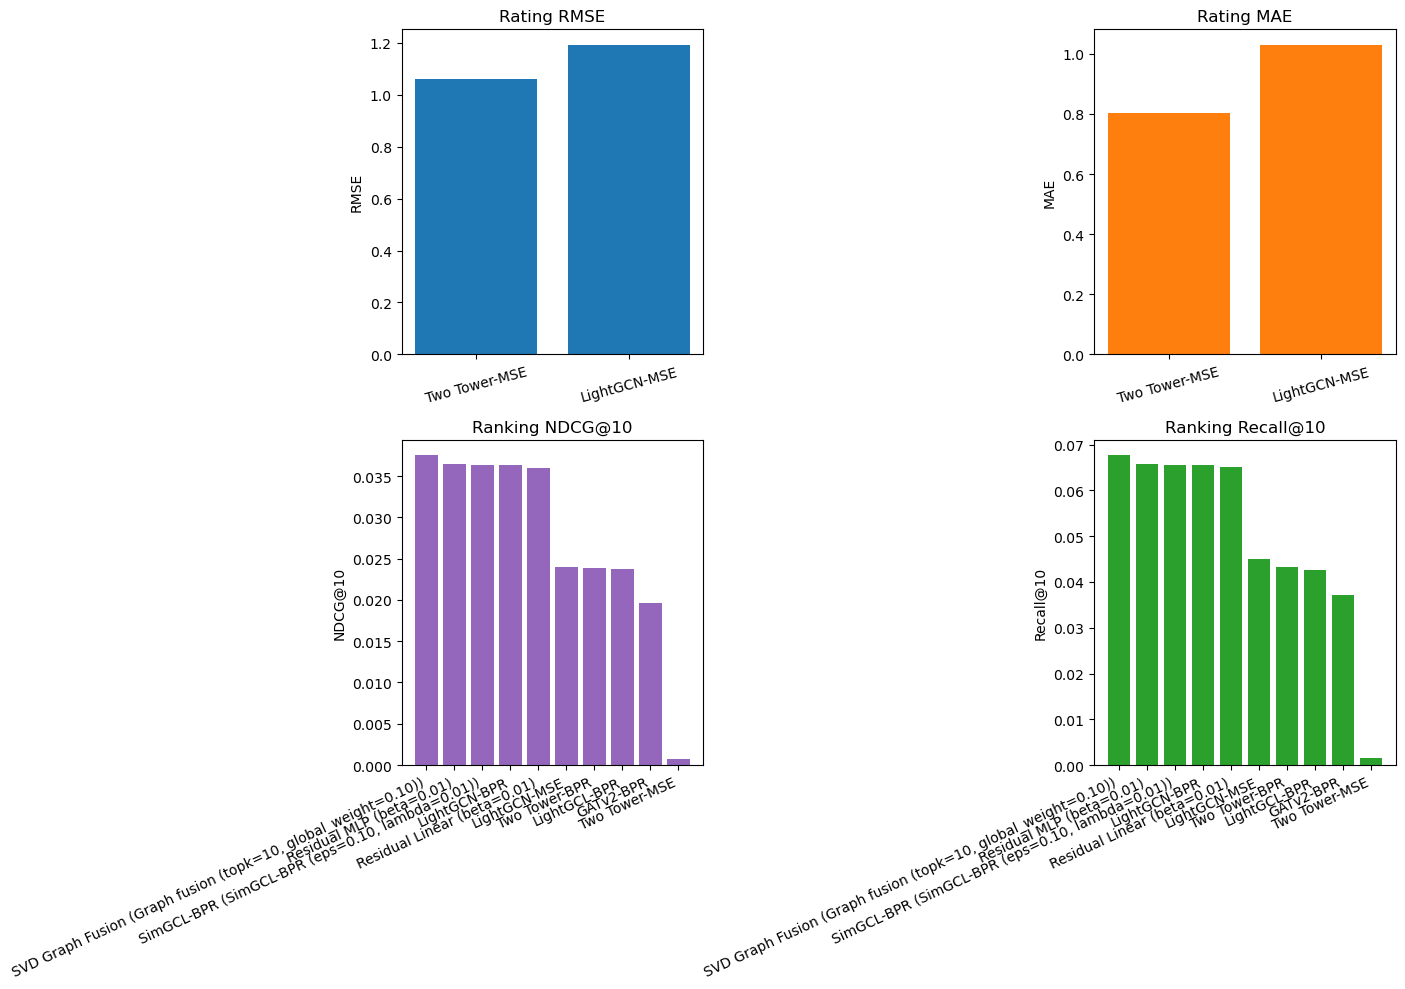

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

rating_models = baseline_rating_summary['Model'].tolist()
x_rating = np.arange(len(rating_models))
axes[0, 0].bar(x_rating, baseline_rating_summary['Test RMSE'], color='tab:blue')
axes[0, 0].set_title('Rating RMSE')
axes[0, 0].set_xticks(x_rating)
axes[0, 0].set_xticklabels(rating_models, rotation=15)
axes[0, 0].set_ylabel('RMSE')

axes[0, 1].bar(x_rating, baseline_rating_summary['Test MAE'], color='tab:orange')
axes[0, 1].set_title('Rating MAE')
axes[0, 1].set_xticks(x_rating)
axes[0, 1].set_xticklabels(rating_models, rotation=15)
axes[0, 1].set_ylabel('MAE')

ranking_sorted_ndcg = ranking_comparison_df.sort_values('NDCG@10', ascending=False).reset_index(drop=True)
x_ndcg = np.arange(len(ranking_sorted_ndcg))
axes[1, 0].bar(x_ndcg, ranking_sorted_ndcg['NDCG@10'], color='tab:purple')
axes[1, 0].set_title('Ranking NDCG@10')
axes[1, 0].set_xticks(x_ndcg)
axes[1, 0].set_xticklabels(ranking_sorted_ndcg['Model'], rotation=25, ha='right')
axes[1, 0].set_ylabel('NDCG@10')

ranking_sorted_recall = ranking_comparison_df.sort_values('Recall@10', ascending=False).reset_index(drop=True)
x_recall = np.arange(len(ranking_sorted_recall))
axes[1, 1].bar(x_recall, ranking_sorted_recall['Recall@10'], color='tab:green')
axes[1, 1].set_title('Ranking Recall@10')
axes[1, 1].set_xticks(x_recall)
axes[1, 1].set_xticklabels(ranking_sorted_recall['Model'], rotation=25, ha='right')
axes[1, 1].set_ylabel('Recall@10')

plt.tight_layout()
plt.show()
